## 🌳 TREA — Tree-Ring Embedding Algorithm for Diffusion Models

The **Tree-Ring Embedding Algorithm (TREA)** introduces a frequency-domain watermarking technique that fine-tunes diffusion models by injecting *radially oscillating patterns* into the Fourier spectrum.  
This produces visually imperceptible yet statistically verifiable watermarks that persist throughout the stochastic denoising process.

---

### 1. Overview

TREA fine-tunes a pretrained diffusion UNet by injecting a **spectrally encoded watermark** into intermediate timesteps $t \le t_A$.  
After $t_A$, the watermark signal propagates naturally through diffusion without further modification.  
This process biases the model toward a **radial frequency signature**, yielding a persistent watermark that can later be detected via spectral correlation.

---

### 2. Watermark Representation

TREA defines a **Tree-Ring pattern** $P(u,v)$ in the 2-D Fourier domain:

$$
P(u,v) = \sin\!\big(2\pi f_r (r(u,v) - r_0)\big),
$$

where  

- $f_r$ is the *radial frequency* controlling the number of oscillations,  
- $r(u,v) = \sqrt{(u-u_c)^2 + (v-v_c)^2}$ is the distance from the spectral center, and  
- $r_0$ is the **reference radius**, defining the approximate location of the Tree-Ring’s central band.  

Unlike annular watermarking—which modulates only a single thin band—TREA applies a *multi-cycle radial sinusoid* centered around $r_0$, forming a **concentric Tree-Ring structure** that smoothly extends across frequency bands.

To preserve energy consistency, the pattern is normalized as

$$
\tilde{P}(u,v) = \frac{(P(u,v) - \mu)}{\sigma},
$$

where $\mu$ and $\sigma$ are the mean and standard deviation across all frequency components.

In practice, for a $32 \times 32$ image (e.g., CIFAR-10), the Nyquist limit is $r_{\text{nyq}} = 16$.  
Setting $r_0 \approx 8\text{–}12$ targets mid-frequency regions, achieving the best trade-off between invisibility and robustness.

---

### 3. Spectral Injection During Fine-Tuning

At each diffusion step $t \le t_A$, the Fourier magnitude of the noised sample is modulated by the Tree-Ring pattern:

$$
|\mathcal{F}(x_t')| = |\mathcal{F}(x_t)|\,\big(1 + \lambda_t\,\tilde{P}(u,v)\big),
$$

where  

- $\mathcal{F}$ denotes the FFT,  
- $\lambda_t = (1 - \gamma) f_2(t)$ controls the time-dependent watermark amplitude, and  
- $\gamma$ balances original and watermarked noise contributions.  

The modulated image is reconstructed by inverse FFT:

$$
x_t' = \mathcal{F}^{-1}\!\Big(|\mathcal{F}(x_t)|(1+\lambda_t\tilde{P})e^{i\angle\mathcal{F}(x_t)}\Big).
$$

---

### 4. Modified Diffusion Target

To guide the denoiser toward the watermark direction, the diffusion target is modified as:

$$
\epsilon'' = \gamma\,\epsilon' + (1 - \gamma)\,K\,x_A,
$$

where $\epsilon' \sim \mathcal{N}(0, I)$ is Gaussian noise, $x_A$ is the watermark reference in the spatial domain, and $K$ scales $f_2(t_A) \approx 1.0$.  
The training loss becomes:

$$
\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon'}\!\big[\|\epsilon_\theta(x_t', t) - \epsilon''\|_2^2\big].
$$

---

### 5. Post-$t_A$ Simulation

For timesteps $t > t_A$, no further watermark is injected.  
Diffusion continues naturally from the watermarked state $x'_{t_A}$ according to:

$$
x_t' = \sqrt{\frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,x'_{t_A}
      + \sqrt{1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,\epsilon',
$$

ensuring consistent propagation of the watermark signal.

---

### 6. Detection via Spectral Correlation

To evaluate watermark strength, generated samples $\bar{x}$ are averaged and their log-magnitude spectra are correlated with $\tilde{P}$:

$$
\rho = \frac{1}{|M|} \sum_{(u,v)}
       \frac{(\log|\mathcal{F}(\bar{x})|-\mu_{\bar{x}})}{\sigma_{\bar{x}}}
       \frac{(\tilde{P}(u,v)-\mu_P)}{\sigma_P}.
$$

A larger correlation coefficient $\rho$ implies stronger watermark retention and better alignment with the Tree-Ring pattern.

---

### 7. Training Algorithm (TREA)

| Step | Description |
|------|--------------|
| **1** | Sample a timestep $t \sim [0,T)$. |
| **2** | If $t \le t_A$: apply Tree-Ring spectral modulation centered at $r_0$. |
| **3** | Compute target $\epsilon'' = \gamma\epsilon' + (1-\gamma)Kx_A$. |
| **4** | Train UNet with loss $\mathcal{L} = \|\epsilon_\theta - \epsilon''\|^2$. |
| **5** | For $t > t_A$: continue diffusion from $x'_{t_A}$. |
| **6** | Detect watermark via spectral correlation $\rho$. |

---

### 8. Key Hyperparameters

| Symbol | Meaning | Typical Value |
|:--:|:--|:--:|
| $r_0$ | Reference ring center (pixels) | 8–12 for 32×32 images |
| $f_r$ | Radial oscillation frequency | 10–20 |
| $\gamma$ | Blending factor | 0.8 |
| $\lambda_{\text{clip}}$ | Max modulation amplitude | 0.02–0.05 |
| $t_A/T$ | Embedding vs. simulation split | 0.75 |
| $f_2(t)$ | Temporal watermark ramp | Normalized cumulative noise weight |

---

### 9. Intuition

- The **Tree-Ring structure** introduces sinusoidal modulation across radial frequencies rather than a single-band mask.  
- The parameter **$r_0$** defines the approximate center of oscillation, shaping how energy is distributed across the frequency spectrum.  
- The modulation is **phase-invariant**, ensuring robustness to translation and rotation.  
- Gradual temporal weighting via $f_2(t)$ maintains imperceptibility and prevents training drift.  
- Verification through **spectral correlation** detects the unique radial signature without requiring access to original data.

---

### 10. Summary

TREA provides a **principled, frequency-domain watermarking framework** for diffusion models.  
By embedding a *Tree-Ring* sinusoidal pattern in the spectral domain and aligning it with the diffusion schedule, TREA achieves:

- **Invisible** watermark embedding,  
- **Statistical detectability**, and  
- **Robust persistence** across diffusion trajectories.


## Setup

In [ ]:
import math, matplotlib.pyplot as plt, cv2, torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from diffusers import DDPMPipeline, DDPMScheduler
import copy
import pandas as pd
import numpy as np
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance, NoTrainInceptionV3
import time
import traceback
from typing import Tuple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


## Config

In [2]:
from dataclasses import dataclass


@dataclass
class Config:
    """
    Central configuration for the paper-exact watermarking demo.
    We keep everything in one place so the training loop, verification,
    and sampling can read consistent values.
    """

    seed = 0
    # ----------------------------
    # Dataset & pretrained weights
    # ----------------------------
    dataset: str = (
        "CIFAR10"  # Which dataset the demo uses. Affects t_A choice and channel count.
    )
    model_id: str = (
        "google/ddpm-cifar10-32"  # Hugging Face repo for a *pretrained* DDPM (32x32, CIFAR-10).
    )

    # ----------------------------
    # Image geometry (must match the model)
    # ----------------------------
    image_size: int = (
        32  # Spatial resolution. Must match the pretrained UNet (here: 32x32).
    )
    channels: int = (
        3  # 3 for RGB datasets (CIFAR/CelebA), 1 for grayscale (MNIST/FashionMNIST).
    )

    # ----------------------------
    # Data loader / fine-tuning subset
    # ----------------------------
    using_subset: bool = (
        True  # Use a subset of the training data for quick fine-tuning (True) or full set (False).
    )
    subset_size: int = (
        5000  # How many training images to fine-tune on (paper trains from scratch; we fine-tune briefly).
    )
    batch_size: int = (
        128  # Larger batches = better signal averaging for the watermark gradient, but use what fits in VRAM.
    )
    num_workers: int = (
        2  # DataLoader workers; increase if the input pipeline becomes the bottleneck.
    )

    # ----------------------------
    # Optimizer / fine-tuning schedule
    # ----------------------------
    lr: float = (
        2e-4  # AdamW learning rate for *fine-tuning*. Keep modest to preserve pretrained fidelity.
    )
    max_steps: int = (
        300  # Number of optimizer steps. 200–500 is a good range; too long can degrade image quality.
    )
    use_ema: bool = (
        True  # Use EMA(0.999) for RGB datasets (as in the paper) to stabilize sampling quality.
    )

    # ----------------------------
    # Watermark controls (Algorithm 1, f1(t)=0)
    # ----------------------------
    gamma: float = (
        0.8  # Paper’s γ. During training, targets are γ·ε' + (1−γ)Kx_A; during sampling we divide outputs by γ.
    )

    # t_A specifies the split between "Embedding" (t ≤ t_A) and "Simulation" (t > t_A).
    # The paper uses: CIFAR/Fashion -> t_A ≈ 3/4·T; MNIST/CelebA -> t_A ≈ 1/2·T.
    tA_frac_cifar: float = 0.75  # fraction of T for CIFAR/Fashion
    tA_frac_other: float = 0.5  # fraction of T for MNIST/CelebA

    # ----------------------------
    # BOX watermark pattern (bottom-right), single channel
    # ----------------------------
    box_size: int = (
        8  # Side length of the filled square watermark in pixels (on a 32x32 canvas).
    )
    box_margin: int = (
        2  # Pixels the box sits *inward* from the bottom and right borders.
    )
    which_channel_rgb: int = (
        1  # Which RGB channel holds the watermark: 0=R, **1=G**, 2=B. We default to green.
    )

    # ----------------------------
    # Sampling (qualitative visualization)
    # ----------------------------
    n_final_samples: int = (
        36  # Number of images to generate for a grid after fine-tuning.
    )
    sample_steps: int = (
        1000  # Reverse-diffusion steps. 1000 ≈ training T (paper-like); 250 is faster but lower fidelity.
    )

    # ----------------------------
    # Verification at t_A (statistical reveal of the watermark)
    # ----------------------------
    verify_batches: int = 32  # How many independent averages to compute for stability.
    verify_batch_size: int = (
        8  # How many trajectories per average at t_A (higher = stronger SNR for the watermark).
    )
    contour_threshold: float = (
        0.3  # Success threshold for ROI-restricted contour distance (lower is better).
    )
    # Tune per dataset/box size; 0.2–0.4 typically works.

    ring_radius = 16
    wtmk_ch = 0
    finetune_sweep = [
        0,
        100,
        300,
        500,
        1000,
    ]  # Ablate fine-tuning steps for verification (e.g. [100,200,300,400]).

    lam_clip: float = 0.02
    f2_scale: float = 1.0


# Materialize the config so downstream code can read `cfg.<field>`.
cfg = Config()
print(cfg)

Config(dataset='CIFAR10', model_id='google/ddpm-cifar10-32', image_size=32, channels=3, using_subset=True, subset_size=5000, batch_size=128, num_workers=2, lr=0.0002, max_steps=300, use_ema=True, gamma=0.8, tA_frac_cifar=0.75, tA_frac_other=0.5, box_size=8, box_margin=2, which_channel_rgb=1, n_final_samples=36, sample_steps=1000, verify_batches=32, verify_batch_size=8, contour_threshold=0.3, lam_clip=0.02, f2_scale=1.0)


## Dataset, selecting the dataset we would like to use, using CIFAR10 here as the pre-trained model we used is

In [ ]:
if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_frac_cifar
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_frac_other
else:
    raise ValueError("Unsupported dataset")


idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx) if cfg.using_subset else trainset
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
len(train_loader)

Files already downloaded and verified


40

In [4]:
# ================================================
# Load pretrained DDPM, extract schedule & buffers
# ================================================
pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
pipe.set_progress_bar_config(disable=False)

# Components
unet = pipe.unet               # ε_θ(x_t, t): predicts noise
scheduler: DDPMScheduler = pipe.scheduler   # holds β_t / α_t and reverse-step logic

# Choose a working dtype for all schedule tensors (float32 is safest)
_sched_dtype = torch.float32

# Training horizon T (number of *training* diffusion steps, typically 1000)
T: int = int(scheduler.config.num_train_timesteps)

# ᾱ_t := ∏_{s=0}^{t} α_s  (cumulative keep-rate). Shape [T].
# Move to the right device/dtype explicitly (some schedulers keep these on CPU by default).
a_bar = scheduler.alphas_cumprod.to(device=device, dtype=_sched_dtype)
assert a_bar.numel() == T, f"alphas_cumprod has {a_bar.numel()} entries but T={T}"

# Recover per-step α_t from ᾱ_t
# α_0 = ᾱ_0 ; for t>=1, α_t = ᾱ_t / ᾱ_{t-1}
alpha = torch.empty_like(a_bar)
alpha[0] = a_bar[0]
denom = a_bar[:-1].clamp(min=1e-12)     # numeric safety
alpha[1:] = (a_bar[1:] / denom)

# Convenience buffers used throughout
sqrt_a_bar    = a_bar.sqrt()            # √ᾱ_t
sqrt_1m_a_bar = (1.0 - a_bar).clamp(min=0.0).sqrt()  # √(1 - ᾱ_t)

# ------------------------------------------------
# Pick the watermark split t_A as a fraction of T
# ------------------------------------------------
# If you have dataset-specific defaults, prefer them; else use a single tA_frac.
if hasattr(cfg, "dataset"):
    ds = str(cfg.dataset).lower()
    if any(k in ds for k in ["cifar", "fashion"]):
        tA_frac = getattr(cfg, "tA_frac_cifar", getattr(cfg, "tA_frac_other", 0.5))
    else:
        tA_frac = getattr(cfg, "tA_frac_other", 0.5)
else:
    # Fallback if no dataset hint is available
    tA_frac = 0.5

# Bound to [0,1] then map to an integer index in [0, T-1]
tA_frac = float(max(0.0, min(1.0, tA_frac)))
tA: int = int(round(tA_frac * (T - 1)))

print(f"T = {T}  |  tA_frac = {tA_frac:.3f}  ->  tA = {tA}")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


T = 1000  |  tA_frac = 0.750  ->  tA = 749


In [5]:
# ============================================================
# Helpers (Tree-Ring–ready): IO, grids, real data, metrics, FT
# ============================================================

from torchmetrics.image.fid import FrechetInceptionDistance
_fid_helper = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
inception_model = _fid_helper.inception.eval()

# ---------------- I/O + display ----------------

def _to01(x: torch.Tensor) -> torch.Tensor:
    """
    Normalize to [0,1] for display/uint8 conversion.
    Accepts [..., C, H, W]. If values look like [-1,1], remap; else just clamp [0,1].
    """
    x = x.detach()
    # treat as [-1,1] if it clearly spans beyond [0,1]
    if (x.min().item() < -0.05) or (x.max().item() > 1.05):
        x = (x.clamp(-1, 1) + 1) * 0.5
    return x.clamp(0, 1)

def show_grid_tensor(imgs: torch.Tensor, title: str = "", nrow: int = None, figsize=6):
    """
    Display a grid given a 4D tensor (B,C,H,W) in either [-1,1] or [0,1].
    - Auto-normalizes to [0,1]
    - Chooses a square-ish grid if nrow is not provided
    """
    assert imgs.dim() == 4, "imgs must be [B,C,H,W]"
    B = imgs.size(0)
    if nrow is None:
        nrow = int(math.ceil(math.sqrt(B)))
    grid = make_grid(_to01(imgs), nrow=nrow, padding=2)
    npimg = (grid.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    plt.figure(figsize=(figsize, figsize) if isinstance(figsize, (int, float)) else figsize)
    plt.imshow(npimg)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def to_u8(x: torch.Tensor) -> torch.Tensor:
    """
    Convert float tensor in either [-1,1] or [0,1] to uint8 [0,255] on CPU.
    Accepts [C,H,W] or [B,C,H,W]; returns same shape on CPU with dtype=uint8.
    """
    x01 = _to01(x)
    return (x01 * 255).round().to(torch.uint8).cpu()

# Back-compat alias
_to_u8_0_255 = to_u8

# ---------------- Real data for metrics ----------------

def _collect_real_u8(train_loader, n: int) -> torch.Tensor:
    """
    Pull ~n real images from the dataloader and convert to uint8 [0,255].
    Robust to loader providing either [-1,1] or [0,1]. Stops early if loader exhausts.
    """
    buf, tot = [], 0
    it = iter(train_loader)
    while tot < n:
        try:
            x, _ = next(it)
        except StopIteration:
            break
        x01 = _to01(x.to(torch.float32))
        buf.append(_to_u8_0_255(x01))
        tot += x.size(0)
    if not buf:
        raise RuntimeError("No real images collected; check your train_loader.")
    return torch.cat(buf, dim=0)[:n]  # [N,C,H,W] uint8 (CPU)

@torch.no_grad()
def _inception_feats_u8(u8_imgs: torch.Tensor, device: torch.device, batch: int = 128) -> torch.Tensor:
    """
    Extract 2048-d Inception (pool3) features for images using the same backbone that
    FrechetInceptionDistance uses internally.
    Args:
        u8_imgs: [N,C,H,W] uint8 on CPU
        device:  torch.device
        batch:   mini-batch size
    Returns:
        feats: [N,2048] float32 on CPU
    """
    from torchmetrics.image.fid import FrechetInceptionDistance
    fid_helper = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inc = fid_helper.inception.eval()

    feats = []
    for i in range(0, u8_imgs.shape[0], batch):
        xb_u8 = u8_imgs[i:i+batch].to(device)  # uint8 on device
        try:
            f = inc(xb_u8)                     # newer torchmetrics accepts uint8
        except Exception:
            xb = xb_u8.float() / 255.0
            f = inc(xb)
        if isinstance(f, (tuple, list)):
            f = f[0]
        feats.append(f.detach().float().cpu())
    del fid_helper
    return torch.cat(feats, dim=0)

@torch.no_grad()
def _precision_recall_knn(
    feats_real: torch.Tensor, feats_fake: torch.Tensor,
    k: int = 3, chunk: int = 1024, device: torch.device = None
):
    """
    Precision/Recall (Kynkäänniemi et al., 2019) on Inception features.
      - Precision: fraction of fake samples within k-NN radius of real neighborhoods
      - Recall:    fraction of real samples within k-NN radius of fake neighborhoods
    Inputs: feats_* on CPU [N,2048]; chunks moved to device for cdist.
    Returns: (precision, recall)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X = feats_real.to(device)  # [Nr, D]
    Y = feats_fake.to(device)  # [Nf, D]

    def knn_radii(A: torch.Tensor, k: int) -> torch.Tensor:
        n = A.size(0)
        rads = torch.empty(n, device=device)
        for i in range(0, n, chunk):
            j = min(i + chunk, n)
            block = A[i:j]                      # [B,D]
            dist = torch.cdist(block, A, p=2)   # [B,n]
            # exclude self-distances for the block rows where it applies
            if A.data_ptr() == block.data_ptr():  # same storage (rare), safeguard anyway
                idx_block = torch.arange(i, j, device=device)
                dist[:, idx_block] = float('inf')
            kth, _ = torch.topk(dist, k, dim=1, largest=False)
            rads[i:j] = kth[:, -1]
        return rads

    r_X = knn_radii(X, k=k)  # [Nr]
    r_Y = knn_radii(Y, k=k)  # [Nf]

    # Precision: ∀ y∈Y, ∃ x∈X s.t. ||y-x|| <= r_X[x]
    prec_hits = torch.zeros(Y.size(0), dtype=torch.bool, device=device)
    for i in range(0, X.size(0), chunk):
        j = min(i + chunk, X.size(0))
        d = torch.cdist(Y, X[i:j], p=2)                # [Nf, j-i]
        thr = r_X[i:j].unsqueeze(0).expand_as(d)       # [Nf, j-i]
        prec_hits |= (d <= thr).any(dim=1)
    precision = float(prec_hits.float().mean().item())

    # Recall: ∀ x∈X, ∃ y∈Y s.t. ||x-y|| <= r_Y[y]
    rec_hits = torch.zeros(X.size(0), dtype=torch.bool, device=device)
    for i in range(0, Y.size(0), chunk):
        j = min(i + chunk, Y.size(0))
        d = torch.cdist(X, Y[i:j], p=2)                # [Nr, j-i]
        thr = r_Y[i:j].unsqueeze(0).expand_as(d)       # [Nr, j-i]
        rec_hits |= (d <= thr).any(dim=1)
    recall = float(rec_hits.float().mean().item())

    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return precision, recall

# ---------------- Fourier helpers (Tree-Ring) ----------------

def fft_log_mag(x01_chw: torch.Tensor, ch: int) -> np.ndarray:
    """log|FFT| for channel ch of a [C,H,W] tensor in [0,1]."""
    x = x01_chw[ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    return np.log1p(np.abs(F).astype(np.float32))

def ring_edge_from_mask(ring_mask: np.ndarray) -> np.ndarray:
    """Thin edge for overlay from a boolean ring/disc mask."""
    m = ring_mask.astype(np.uint8)
    return np.logical_xor(m, np.pad(m, 1)[1:-1, 1:-1])

def spectral_correlation_score_tree_ring(
    x01_chw: torch.Tensor, ring_mask: np.ndarray, ring_patt: np.ndarray, wtmk_ch: int
) -> float:
    """
    Pearson correlation on the ring between z-scored |FFT(x)| and z-scored pattern magnitude.
    Returns scalar in [-1,1]; higher = stronger watermark.
    """
    x = x01_chw[wtmk_ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    mag = np.abs(F).astype(np.float32)

    M = ring_mask.astype(bool)
    if M.sum() < 16:
        return 0.0

    z = (mag[M] - mag[M].mean()) / (mag[M].std() + 1e-6)

    patt_mag = np.abs(ring_patt).astype(np.float32)
    p = (patt_mag[M] - patt_mag[M].mean()) / (patt_mag[M].std() + 1e-6)

    return float((z * p).mean())

# ---------------- Fine-tune scope control ----------------

def set_trainable(unet, mode: str = "last_block"):
    """
    mode ∈ {"all","last_conv","last_block","last_two_blocks"}.
      - "last_conv": only final conv_norm_out + conv_out heads
      - "last_block": last up block + conv heads (recommended)
      - "last_two_blocks": last two up blocks + conv heads
      - "all": train everything (heavier; more drift risk)

    Freezes all params, then re-enables the chosen modules.
    Prints how many parameters are trainable.
    """
    for p in unet.parameters():
        p.requires_grad = False

    if mode == "all":
        modules = [unet]
    elif mode == "last_conv":
        modules = [unet.conv_norm_out, unet.conv_out]
    elif mode == "last_block":
        modules = [unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    elif mode == "last_two_blocks":
        modules = [unet.up_blocks[-2], unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    else:
        raise ValueError(f"Unknown mode: {mode}")

    for m in modules:
        for p in m.parameters():
            p.requires_grad = True

    tot = sum(p.numel() for p in unet.parameters())
    trn = sum(p.numel() for p in unet.parameters() if p.requires_grad)
    print(f"Trainable params: {trn/1e6:.2f}M / {tot/1e6:.2f}M  ({100*trn/tot:.1f}%), mode='{mode}'")


# Part 1 — Baseline (pretrained) samples

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


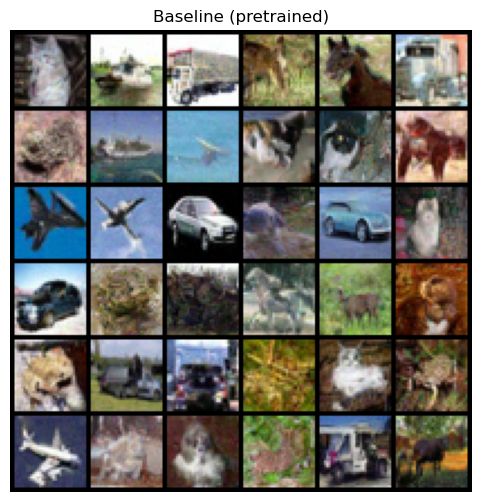

In [6]:
@torch.no_grad()
def sample_pretrained(pipe, num=36, steps=250):
    """Sample from the pretrained model for qualitative visualization."""
    out = pipe(batch_size=num, num_inference_steps=steps)
    arr = []
    for im in out.images:
        arr.append(torch.from_numpy(np.array(im).astype("float32")/255.0).permute(2,0,1))
    return torch.stack(arr, dim=0)

baseline_imgs = sample_pretrained(pipe, num=cfg.n_final_samples, steps=250)
show_grid_tensor(baseline_imgs, "Baseline (pretrained)")


## Paper watermark x_A: bottom‑right **box** (single channel)

Tree-Ring watermark → xA set on channel 0 | mean: -3.1044087300813317e-09 | rms: 0.577444314956665


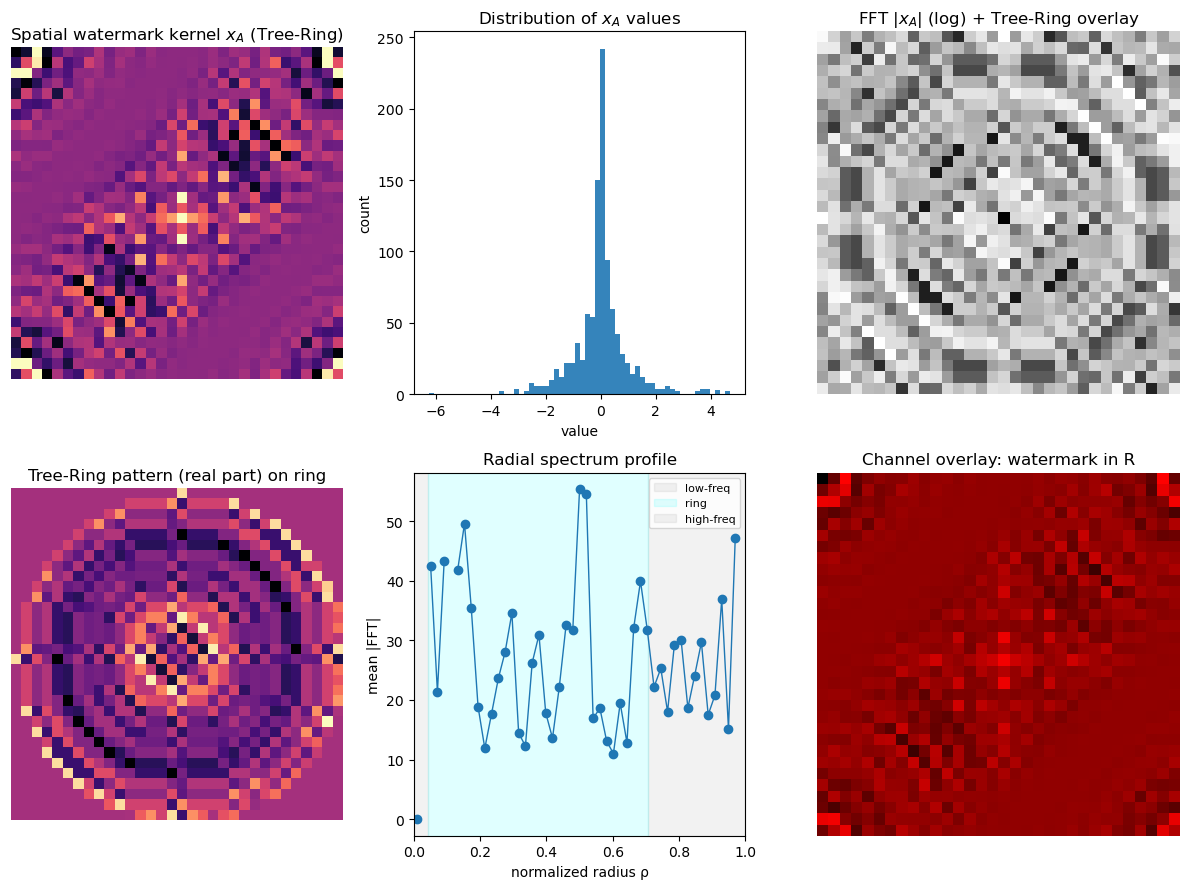

xA stats — mean=0.0000e+00, std=1.0000, min=-6.266, max=4.721
Ring coverage: 794 / 1024 pixels (77.5%)


In [7]:
# ========== Fourier watermark (Tree-Ring → spatial xA) ==========
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt

def _build_tree_ring_fourier(H, W, *, radius: int, seed: int, channels: int = 1, device="cpu"):
    """
    Paper-style Tree-Ring pattern (radius-only):
      1) Start from random spatial latents -> FFT (shifted)
      2) Copy values over concentric *discs* up to 'radius' (like your 'ring' branch)
      3) Return complex Fourier patch (fftshifted) and a boolean ring mask.

    Returns:
      gt_patch: complex tensor [1, C, H, W] in Fourier domain (fftshifted)
      ring_mask: np.bool_ [H, W] (disc of radius 'radius', DC excluded)
    """
    # init random field
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)

    gt_init = torch.randn(1, channels, H, W, device=device)
    gt_patch = torch.fft.fftshift(torch.fft.fft2(gt_init), dim=(-1, -2))  # complex
    gt_patch_tmp = gt_patch.clone()

    # disc mask builder (centered)
    def _disc_mask(size, r):
        yy, xx = np.ogrid[:size, :size]
        cy = cx = size // 2
        # note: the original code flips y, but that only rotates the spectrum, not needed for the mask
        return ((yy - cy)**2 + (xx - cx)**2) <= (r**2)

    # copy values across concentric discs up to 'radius'
    for r in range(radius, 0, -1):
        tmp_mask = _disc_mask(H, r)  # (H,W) bool
        tmp_mask = torch.tensor(tmp_mask, dtype=torch.bool, device=device)
        # match the paper-style indexing used in your snippet: take a single reference pixel per channel
        for j in range(channels):
            gt_patch[:, j, tmp_mask] = gt_patch_tmp[0, j, 0, r].item()

    # final ring (disc) mask for visualization / detection
    ring_mask = _disc_mask(H, radius)
    ring_mask[H//2, W//2] = False  # never touch DC
    return gt_patch, ring_mask

def build_tree_ring_watermark_spatial(H, W, *, radius: int, seed: int = 0, lam: float = 1.0, channels: int = 1, device="cpu"):
    """
    Build a *spatial* kernel xA whose FFT has the paper Tree-Ring support.

    Returns:
      xA_spatial: [H,W] float32, zero-mean, unit-RMS spatial kernel for one channel
      PATT_REAL:  [H,W] float32, real-valued Fourier pattern (used like your previous PN)
      RING_MASK:  [H,W] bool ring/disc mask (used like your previous ANNULUS)
    """
    gt_patch, ring_mask = _build_tree_ring_fourier(H, W, radius=radius, seed=seed, channels=channels, device=device)
    # Use the *real* part for a phase-free magnitude-style target (stable for detection)
    patt = gt_patch[0, 0]                      # complex [H,W]
    PATT_REAL = patt.real.detach().cpu().numpy().astype(np.float32)

    # Enforce Hermitian symmetry on the real-valued pattern so IFFT is purely real
    PATT_REAL = 0.5 * (PATT_REAL + np.flipud(np.fliplr(PATT_REAL)))

    # Build spatial kernel: inverse FFT of (scaled) real Fourier pattern
    F = np.fft.ifftshift(PATT_REAL * lam)
    xA = np.fft.ifft2(F).real.astype(np.float32)

    # Normalize to zero-mean and unit RMS so your time-scaling governs energy
    xA -= xA.mean()
    rms = np.sqrt((xA**2).mean()) + 1e-8
    xA /= rms
    return xA, PATT_REAL, ring_mask

# ---- Build xA for your chosen channel (keeps your injection code intact) ----
H = W = cfg.image_size
channels = cfg.channels
device = "cuda" if torch.cuda.is_available() else "cpu"

WTMK_CH = 0 if channels == 1 else int(cfg.wtmk_ch)

# Use Tree-Ring radius (paper-style). If you kept cfg.ring_params, take its first radius;
# otherwise pick an explicit integer (e.g., 16 for 256×256).
radius = int(cfg.ring_radius)

xA_sp, PATT_REAL, RING_MASK = build_tree_ring_watermark_spatial(
    H, W, radius=radius, seed=cfg.seed, lam=1.0, channels=channels, device=device
)

# Preserve your downstream variable names:
xA = torch.zeros(channels, H, W, dtype=torch.float32, device=device)
xA[WTMK_CH] = torch.from_numpy(xA_sp).to(device)

PN = PATT_REAL          # keep name 'PN' to avoid touching other code
ANNULUS = RING_MASK     # keep name 'ANNULUS' to avoid touching other code

print("Tree-Ring watermark → xA set on channel", WTMK_CH, "| mean:", float(xA.mean()), "| rms:", float(xA.std()))
assert 'xA' in globals() and 'PN' in globals() and 'ANNULUS' in globals()

# ================== Visualization (updated labels: 'ring') ==================
# 1) Spatial kernel placed into channel WTMK_CH
xA_ch = xA[WTMK_CH].detach().cpu().numpy().astype(np.float32)   # [H,W]

# 2) Spectrum of the spatial kernel
F = np.fft.fftshift(np.fft.fft2(xA_ch))
mag = np.abs(F).astype(np.float32)
mag_log = np.log1p(mag)  # log for visibility

# 3) Pattern limited to the ring mask
PN_vis = PN.copy()
PN_vis[~ANNULUS] = 0.0

# 4) Small radial profile (for curiosity)
yy, xx = np.mgrid[-H//2:H-H//2, -W//2:W-W//2]
rr = np.sqrt(yy**2 + xx**2)
rmax_nyq = 0.5*np.sqrt(H**2 + W**2)
rho = rr / rmax_nyq   # normalized radius in [0,1]
bins = np.linspace(0, 1.0, 50)
rad_prof = []
for i in range(len(bins)-1):
    m = (rho >= bins[i]) & (rho < bins[i+1])
    rad_prof.append(mag[m].mean() if m.any() else np.nan)
rad_prof = np.array(rad_prof, dtype=np.float32)

def _channel_overlay(box: np.ndarray, ch: int):
    rgb = np.zeros((H, W, 3), dtype=np.float32)
    if xA.shape[0] == 3:
        rgb[..., ch] = (box - box.min()) / (box.max() - box.min() + 1e-6)
    else:
        rgb[..., :] = (box - box.min()) / (box.max() - box.min() + 1e-6)
    return rgb

# ---- Plot ----
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 3, width_ratios=[1,1,1.1])

# (a) Spatial kernel heatmap
ax = fig.add_subplot(gs[0,0])
v = np.percentile(xA_ch, [1, 99])
ax.imshow(xA_ch, cmap='magma', vmin=v[0], vmax=v[1])
ax.set_title("Spatial watermark kernel $x_A$ (Tree-Ring)")
ax.axis('off')

# (b) Histogram of spatial values (zero-mean, ~unit RMS)
ax = fig.add_subplot(gs[0,1])
ax.hist(xA_ch.flatten(), bins=60, alpha=0.9)
ax.set_title("Distribution of $x_A$ values")
ax.set_xlabel("value")
ax.set_ylabel("count")

# (c) Spectrum magnitude (log) with ring overlay
ax = fig.add_subplot(gs[0,2])
ax.imshow(mag_log, cmap='gray')
ring = ANNULUS.astype(np.uint8)
contour = np.logical_xor(ring, np.pad(ring, 1)[1:-1,1:-1])  # cheap edge
ys, xs = np.where(contour)
ax.plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
ax.set_title("FFT |$x_A$| (log) + Tree-Ring overlay")
ax.axis('off')

# (d) Pattern on ring (real part, zero elsewhere)
ax = fig.add_subplot(gs[1,0])
ax.imshow(PN_vis, cmap='magma')
ax.set_title("Tree-Ring pattern (real part) on ring")
ax.axis('off')

# (e) Radial profile of spectrum magnitude
ax = fig.add_subplot(gs[1,1])
centers = 0.5*(bins[:-1] + bins[1:])
ax.plot(centers, rad_prof, marker='o', lw=1)
ax.axvspan(0, np.min(rho[ANNULUS]), color='k', alpha=0.05, label='low-freq')
ax.axvspan(np.min(rho[ANNULUS]), np.max(rho[ANNULUS]), color='cyan', alpha=0.12, label='ring')
ax.axvspan(np.max(rho[ANNULUS]), 1.0, color='k', alpha=0.05, label='high-freq')
ax.set_xlim(0, 1.0)
ax.set_xlabel("normalized radius ρ")
ax.set_ylabel("mean |FFT|")
ax.set_title("Radial spectrum profile")
ax.legend(fontsize=8, loc='upper right')

# (f) Channel overlay (which channel carries the watermark)
ax = fig.add_subplot(gs[1,2])
overlay = _channel_overlay(xA_ch, WTMK_CH)
ax.imshow(overlay)
if xA.shape[0] == 3:
    ch_name = {0:'R', 1:'G', 2:'B'}.get(WTMK_CH, str(WTMK_CH))
    ax.set_title(f"Channel overlay: watermark in {ch_name}")
else:
    ax.set_title("Grayscale overlay")
ax.axis('off')

plt.tight_layout()
plt.show()

# Quick numeric summary
print(f"xA stats — mean={xA_ch.mean():.4e}, std={xA_ch.std():.4f}, min={xA_ch.min():.3f}, max={xA_ch.max():.3f}")
print(f"Ring coverage: {ANNULUS.sum()} / {H*W} pixels ({100.0*ANNULUS.mean():.1f}%)")


In [8]:
# =============================================
# ✅ Watermark weighting schedule for Tree-Ring
# =============================================
# Works for training-time spatial injection with the xA you built from Tree-Ring.

device = xA.device
dtype  = xA.dtype

# Ensure schedule tensors are on the same device/dtype
alpha   = alpha.to(device=device, dtype=dtype)     # [T] α_t
a_bar   = a_bar.to(device=device, dtype=dtype)     # [T] \bar α_t
sqrt_1m_a_bar = torch.sqrt(torch.clamp(1 - a_bar, min=1e-12))  # [T]

# --- 1) Per-timestep "noise weight"
# h_t ≈ (1 - α_t) / sqrt(1 - \bar α_t)
h = (1 - alpha) / torch.clamp(sqrt_1m_a_bar, min=1e-12)        # [T]

# --- 2) Cumulative ramp (smooth rise)
cumsum_h = torch.cumsum(h, dim=0)                               # [T]

# --- 3) Normalize to ~1 at t_A and zero after t_A
K = 1.0 / float(cumsum_h[tA].item())                            # scalar
f2 = K * cumsum_h                                               # [T]
# keep injection only up to t_A
mask_upto_tA = torch.arange(len(f2), device=f2.device) <= int(tA)
f2 = f2 * mask_upto_tA.to(f2.dtype)

# (Optional) constant-strength replacement:
# f2 = torch.ones_like(a_bar); f2[~mask_upto_tA] = 0

# --- 4) Noise matching term
dyn_scale = sqrt_1m_a_bar                                       # [T]

# --- 5) Gather helper for per-sample timesteps
def gather(arr_1d: torch.Tensor, t_idx: torch.Tensor):
    # arr_1d: [T], t_idx: [B] long
    return arr_1d.index_select(0, t_idx).view(-1, 1, 1, 1)      # [B,1,1,1]

# --- 6) Initial reference term for centering
b0 = f2[0] * xA                                                 # [C,H,W]

# ✅ Sanity
print(f"Normalization constant K = {float(K):.6f}")
print(f"f2[tA] ≈ {float(f2[tA]):.4f} (should be ~1.0)")
print(f"f2 after tA zero? {bool((f2[tA+1:] == 0).all()) if tA+1 < len(f2) else True}")

Normalization constant K = 0.142318
f2[tA] ≈ 1.0000 (should be ~1.0)
f2 after tA zero? True


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


[Baseline]    Spectral correlation (ring): 0.0596
[Watermarked] Spectral correlation (ring): -0.0283


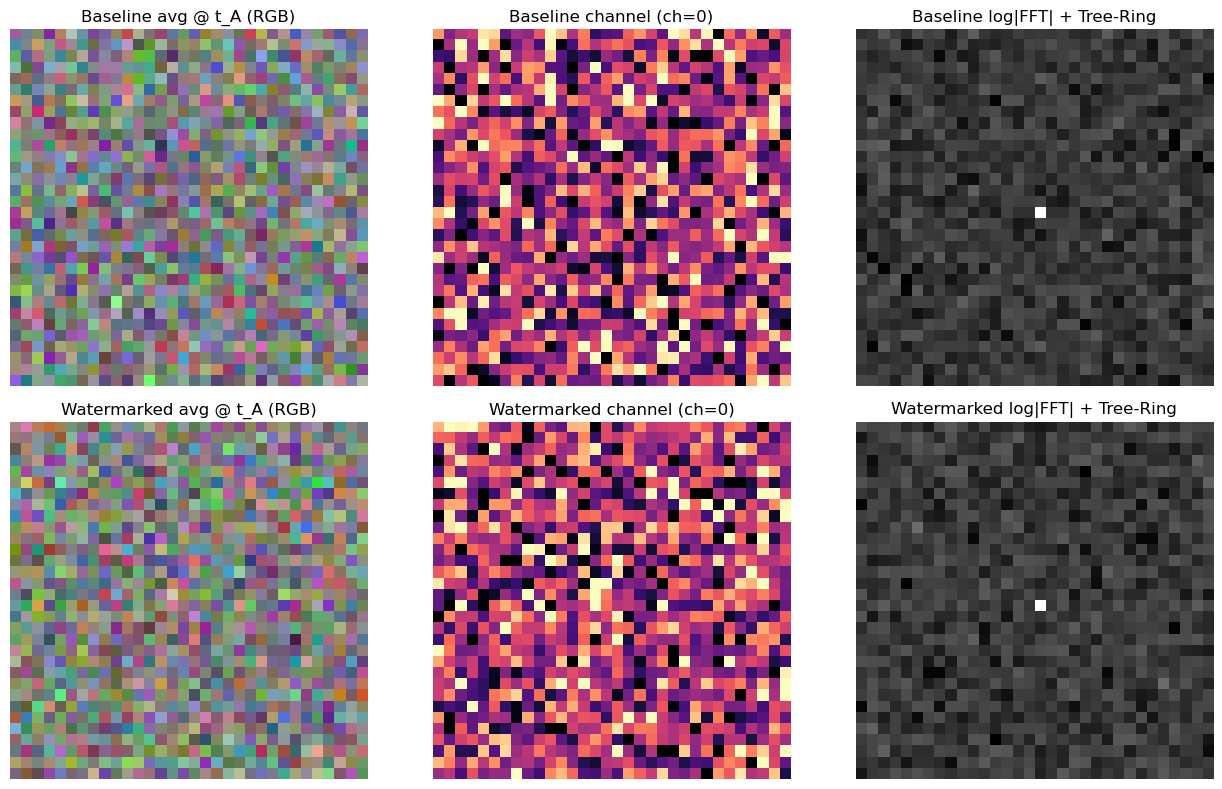

In [12]:
# =============================================
# Load clean baseline pipeline (unchanged)
# =============================================
baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler

# If you still have old names around, keep them compatible:
if 'PN' in globals() and 'ANNULUS' in globals():
    ring_patt = PN          # [H,W] (real or complex); detector uses real/abs
    ring_mask = ANNULUS     # [H,W] bool

# ---------------------------------------------
# Utility: clamp [0,1] → uint8 [0,255] (CPU)
# ---------------------------------------------
def _to_u8_0_255(x01: torch.Tensor) -> torch.Tensor:
    return (x01.clamp(0,1) * 255).to(torch.uint8).cpu()

# -----------------------------------------------------------
# Paper-exact sampler (NO injection during sampling)
# (identical to your version)
# -----------------------------------------------------------
@torch.no_grad()
def sample_paper(unet_like, scheduler_like, n=36, steps=1000, capture_tA=None, gamma=0.8):
    unet_like.eval()
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps  # descending training indices

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    cap_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        cap_idx = int(torch.argmin(diffs).item())

    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if cap_idx is not None and i == cap_idx:
            x_tA = x.clone()

    # Undo gamma scaling (f1=0) and map to [0,1]
    x = (x / gamma)
    if x_tA is not None:
        x_tA = (x_tA / gamma)

    x = ((x.clamp(-1, 1) + 1) * 0.5).detach()
    if x_tA is not None:
        x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x, x_tA

@torch.no_grad()
def _generate_u8(unet_like, scheduler_like, n: int, steps: int, gamma: float) -> torch.Tensor:
    bs, out, left = min(256, n), [], n
    while left > 0:
        cur = min(bs, left)
        imgs, _ = sample_paper(unet_like, scheduler_like, n=cur, steps=steps, capture_tA=None, gamma=gamma)
        out.append(_to_u8_0_255(imgs))
        left -= cur
    return torch.cat(out, dim=0)[:n]

@torch.no_grad()
def _sample_mid_after(unet_like, scheduler_like, n=128, steps=1000, capture_tA=None, gamma=0.8):
    assert capture_tA is not None
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    x_tA = (x_tA / cfg.gamma)
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA  # [N,C,H,W] in [0,1]

# -----------------------------------------------------------
# Baseline mid-state @ t_A (no watermark) for comparison
# -----------------------------------------------------------
xmid_base = _sample_mid_after(baseline_unet, baseline_sched,
                              n=cfg.verify_batch_size, steps=cfg.sample_steps,
                              capture_tA=tA, gamma=cfg.gamma)
xavg_base = xmid_base.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
ch_base   = xavg_base[0, WTMK_CH].cpu().numpy()
lo_b, hi_b = np.percentile(ch_base, [5, 95])

# ----------------------------------------------------------------------
# Diagnostic sampler with **Tree-Ring** Fourier injection (mid-steps)
# ----------------------------------------------------------------------
@torch.no_grad()
def sample_mid_with_tree_ring_injection(unet_like, scheduler_like,
                                        n=128, steps=cfg.sample_steps,
                                        capture_tA=tA, gamma=cfg.gamma,
                                        lam_clip=0.02, f2_scale: float = 1.0):
    """
    Diagnostic sampler: at t <= t_A, apply small multiplicative magnitude modulation
    on the watermark channel in FFT: |F| <- |F| * (1 + λ_t * patt_std) on ring_mask.
    This is for *visual confirmation*; paper-exact sampling does NOT inject.

    Requires the global (or enclosing) variables:
      - ring_mask: [H,W] bool
      - ring_patt: [H,W] (complex or real); we use its real part standardized on the mask
      - f2: per-timestep weighting array in [0,1] (optional but recommended)
    """
    assert 'ring_mask' in globals() and 'ring_patt' in globals(), "Build ring_mask/ring_patt first."
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    # precompute standardized pattern on the mask (phase-free)
    patt_real = np.real(ring_patt).astype(np.float32)
    m = ring_mask.astype(bool)
    mu, sd = patt_real[m].mean(), patt_real[m].std() + 1e-6
    patt_std = np.zeros_like(patt_real, dtype=np.float32)
    patt_std[m] = (patt_real[m] - mu) / sd  # zero off-mask

    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw))
        mag, ph = np.abs(Xi), np.angle(Xi)
        gain = 1.0 + np.clip(lam, -lam_clip, lam_clip) * patt_std  # zero off-mask
        Xi2 = np.fft.ifftshift((mag * gain) * np.exp(1j * ph))
        return np.fft.ifft2(Xi2).real.astype(np.float32)

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        t_idx = int(tt.item())
        if t_idx <= capture_tA:
            lam_t = float(((1.0 - gamma) * f2[t_idx]).clamp(min=0.0).item())
            x_np = x[:, WTMK_CH].detach().cpu().numpy().astype(np.float32)
            for k in range(x_np.shape[0]):
                x_np[k] = _spectral_mod_one(x_np[k], lam=lam_t)
            x[:, WTMK_CH] = torch.from_numpy(x_np).to(x.device)

        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    # Undo gamma (f1=0) and map to [0,1]
    x_tA = (x_tA / gamma)
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA

xmid_inj = sample_mid_with_tree_ring_injection(baseline_unet, baseline_sched,
                                               n=cfg.verify_batch_size, steps=cfg.sample_steps,
                                               capture_tA=tA, gamma=cfg.gamma,
                                               lam_clip=cfg.lam_clip, f2_scale=cfg.f2_scale)
xavg_inj = xmid_inj.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]

# # ----------------------------------------------------------------------
# # Frequency-domain detection (masked correlation on Tree-Ring)
# # ----------------------------------------------------------------------
# def spectral_correlation_score_tree_ring(x01_chw: torch.Tensor,
#                                          ring_mask: np.ndarray,
#                                          ring_patt: np.ndarray,
#                                          wtmk_ch: int) -> float:
#     """
#     Pearson correlation on the ring between z-scored |FFT(x)| and z-scored pattern magnitude.
#     Returns scalar in [-1,1]; higher = stronger watermark.
#     """
#     x = x01_chw[wtmk_ch].detach().cpu().numpy().astype(np.float32)
#     F = np.fft.fftshift(np.fft.fft2(x))
#     mag = np.abs(F).astype(np.float32)

#     M = ring_mask.astype(bool)
#     if M.sum() < 16:
#         return 0.0

#     vals = mag[M]
#     z = (vals - vals.mean()) / (vals.std() + 1e-6)

#     patt_mag = np.abs(ring_patt).astype(np.float32)
#     p = patt_mag[M]
#     p = (p - p.mean()) / (p.std() + 1e-6)

#     return float((z * p).mean())

score_base = spectral_correlation_score_tree_ring(xavg_base[0], ring_mask, ring_patt, WTMK_CH)
score_wtmk = spectral_correlation_score_tree_ring(xavg_inj[0],  ring_mask, ring_patt, WTMK_CH)
print(f"[Baseline]    Spectral correlation (ring): {score_base:.4f}")
print(f"[Watermarked] Spectral correlation (ring): {score_wtmk:.4f}")

# ----------------------------------------------------------------------
# Visualization: spatial average + spectrum with ring overlay
# ----------------------------------------------------------------------
def _fft_log(x01_chw: torch.Tensor, ch: int):
    x = x01_chw[ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    return np.log1p(np.abs(F).astype(np.float32))

mag_base = _fft_log(xavg_base[0], WTMK_CH)
mag_wtmk = _fft_log(xavg_inj[0],  WTMK_CH)

ring_edge = np.logical_xor(ring_mask, np.pad(ring_mask, 1)[1:-1,1:-1])

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# Row 1: Baseline
axes[0,0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy()); axes[0,0].set_title("Baseline avg @ t_A (RGB)"); axes[0,0].axis("off")
axes[0,1].imshow(ch_base, cmap="magma", vmin=lo_b, vmax=hi_b); axes[0,1].set_title(f"Baseline channel (ch={WTMK_CH})"); axes[0,1].axis("off")
axes[0,2].imshow(mag_base, cmap="gray"); ys, xs = np.where(ring_edge); axes[0,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[0,2].set_title("Baseline log|FFT| + Tree-Ring"); axes[0,2].axis("off")

# Row 2: Watermarked (diagnostic Fourier injection)
ch_wtmk = xavg_inj[0, WTMK_CH].cpu().numpy()
lo_w, hi_w = np.percentile(ch_wtmk, [5, 95])
axes[1,0].imshow(xavg_inj[0].permute(1,2,0).cpu().numpy()); axes[1,0].set_title("Watermarked avg @ t_A (RGB)"); axes[1,0].axis("off")
axes[1,1].imshow(ch_wtmk, cmap="magma", vmin=lo_w, vmax=hi_w); axes[1,1].set_title(f"Watermarked channel (ch={WTMK_CH})"); axes[1,1].axis("off")
axes[1,2].imshow(mag_wtmk, cmap="gray"); ys, xs = np.where(ring_edge); axes[1,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[1,2].set_title("Watermarked log|FFT| + Tree-Ring"); axes[1,2].axis("off")

plt.tight_layout(); plt.show()


Running fine-tuning sweep (all layers) + attacks…
=== finetune_and_report start (max_steps=0) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.05s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 0 steps: 0it [00:05, ?it/s]


[DONE] 3) Run fine-tuning in 5.84s (cumulative 5.89s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 12.74s (cumulative 18.63s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 19.68s (cumulative 38.31s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 432.58s (cumulative 470.89s)

[STEP] 7) Build summary figure ...


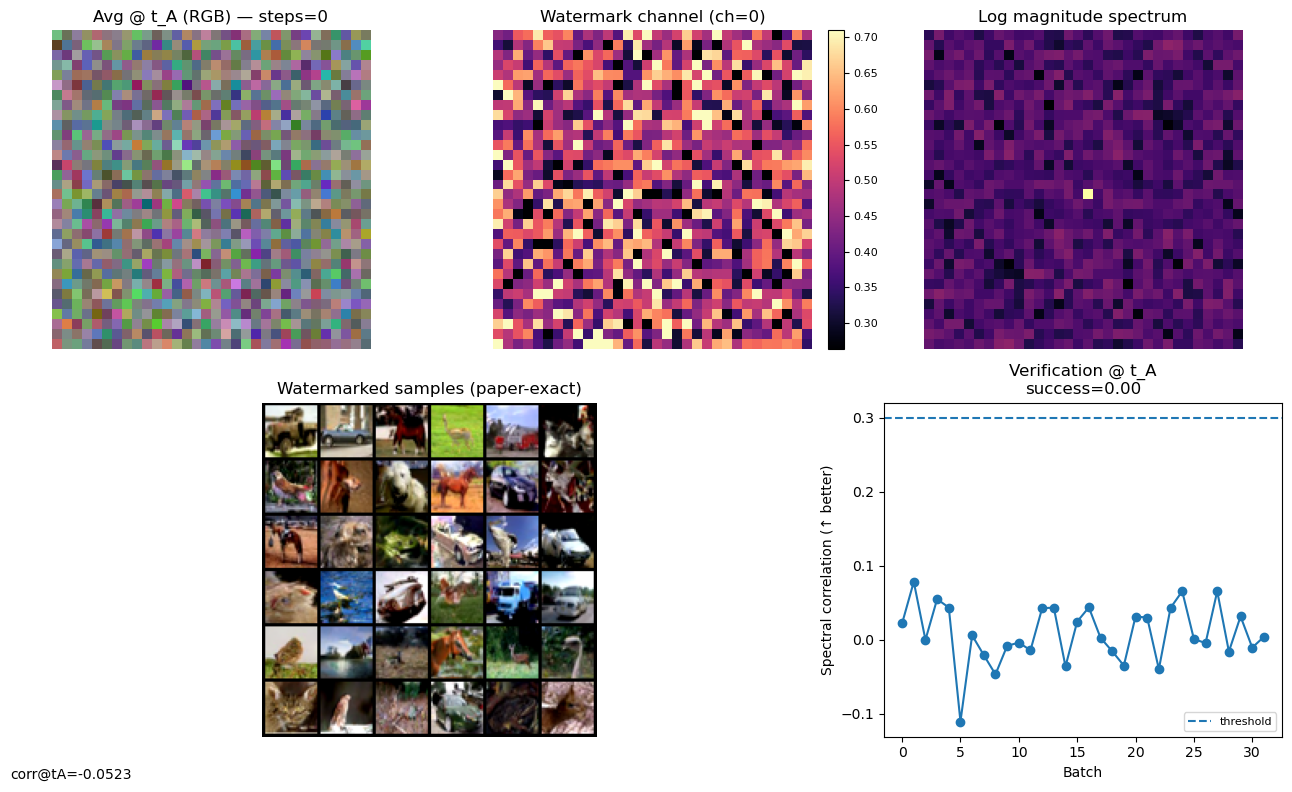

[DONE] 7) Build summary figure in 0.25s (cumulative 471.15s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] collecting real feats failed: Expecting image as torch.Tensor with dtype=torch.uint8
[DONE] 8) Compute quality metrics (optional) in 5.66s (cumulative 476.81s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 476.81s)

=== finetune_and_report done in 476.81s ===
=== finetune_and_report start (max_steps=100) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.05s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 100 steps: 100%|██████████| 100/100 [00:35<00:00,  2.82it/s, loss=0.0703]


[DONE] 3) Run fine-tuning in 35.83s (cumulative 35.88s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 14.72s (cumulative 50.60s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 19.82s (cumulative 70.42s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 478.68s (cumulative 549.10s)

[STEP] 7) Build summary figure ...


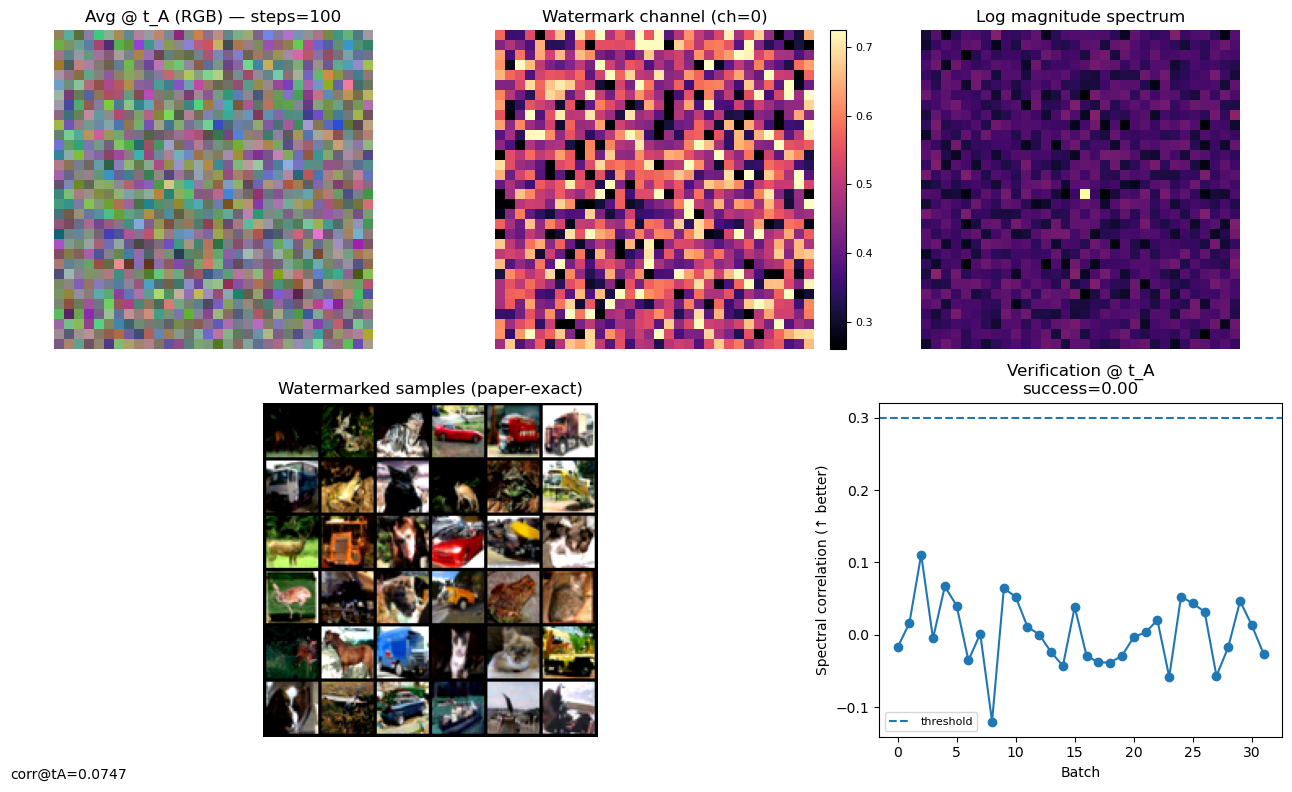

[DONE] 7) Build summary figure in 0.30s (cumulative 549.40s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] collecting real feats failed: Expecting image as torch.Tensor with dtype=torch.uint8
[DONE] 8) Compute quality metrics (optional) in 5.85s (cumulative 555.25s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 555.25s)

=== finetune_and_report done in 555.25s ===
=== finetune_and_report start (max_steps=300) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.05s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 300 steps: 100%|██████████| 300/300 [01:37<00:00,  3.07it/s, loss=0.0652]


[DONE] 3) Run fine-tuning in 97.94s (cumulative 97.99s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 13.01s (cumulative 111.00s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 17.71s (cumulative 128.72s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 428.78s (cumulative 557.50s)

[STEP] 7) Build summary figure ...


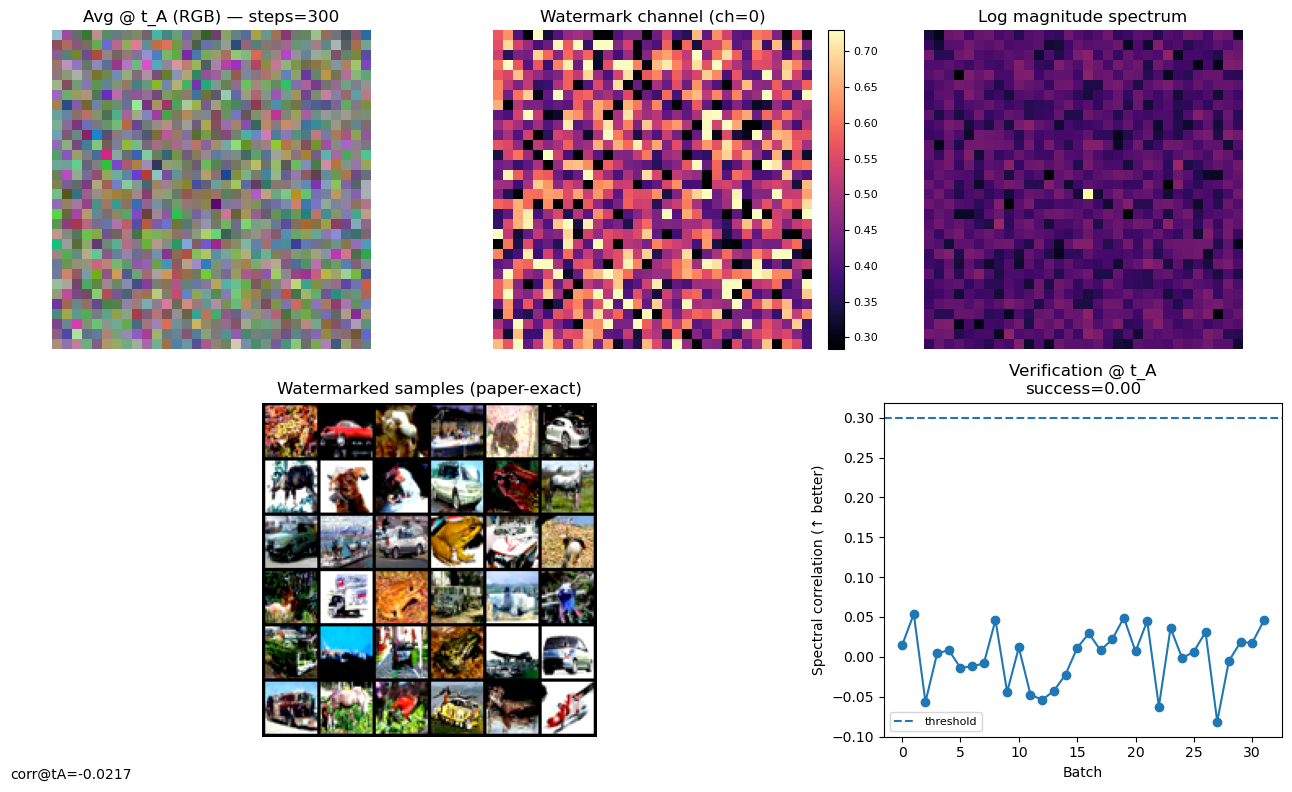

[DONE] 7) Build summary figure in 0.25s (cumulative 557.76s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] collecting real feats failed: Expecting image as torch.Tensor with dtype=torch.uint8
[DONE] 8) Compute quality metrics (optional) in 5.51s (cumulative 563.26s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 563.26s)

=== finetune_and_report done in 563.27s ===
=== finetune_and_report start (max_steps=500) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.04s (cumulative 0.04s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 500 steps: 100%|██████████| 500/500 [02:40<00:00,  3.12it/s, loss=0.0714] 


[DONE] 3) Run fine-tuning in 160.73s (cumulative 160.77s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 13.03s (cumulative 173.81s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 18.56s (cumulative 192.36s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 453.19s (cumulative 645.55s)

[STEP] 7) Build summary figure ...


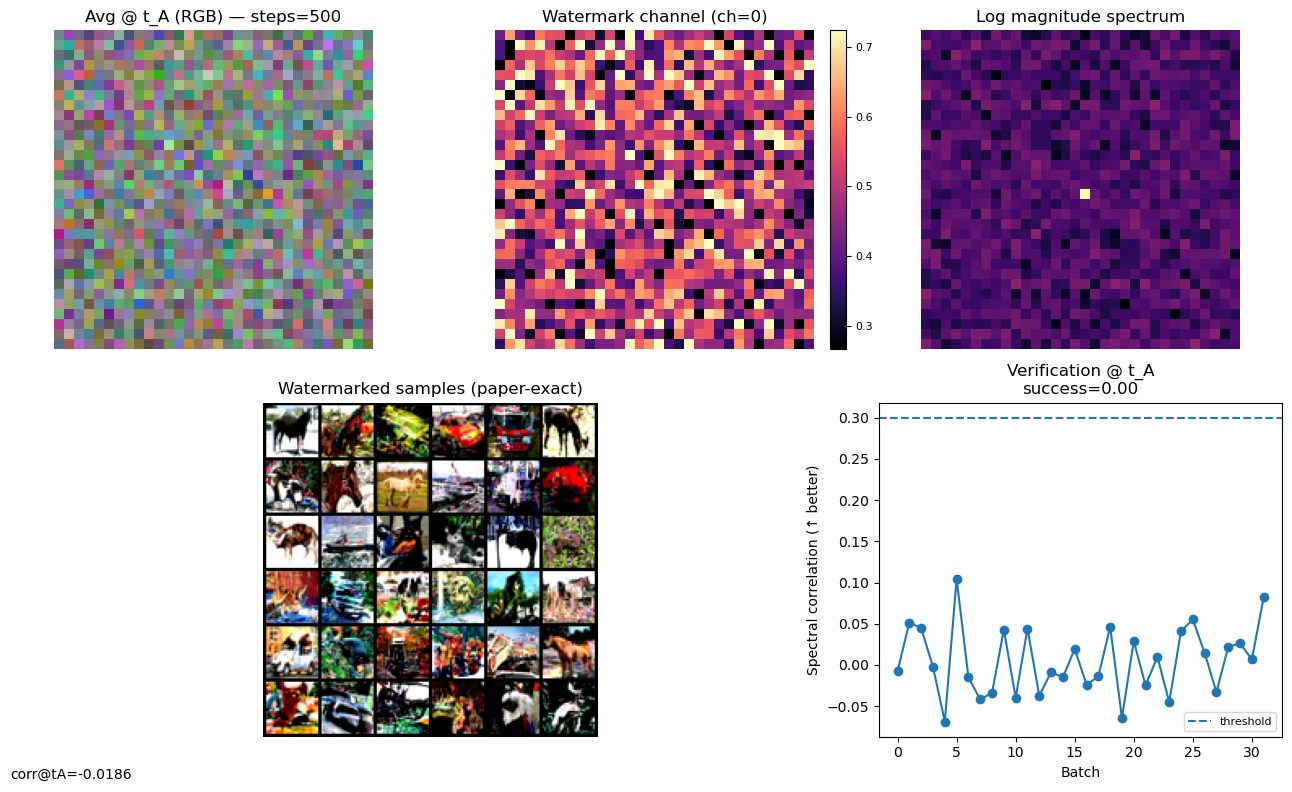

[DONE] 7) Build summary figure in 0.25s (cumulative 645.80s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] collecting real feats failed: Expecting image as torch.Tensor with dtype=torch.uint8
[DONE] 8) Compute quality metrics (optional) in 5.90s (cumulative 651.71s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 651.71s)

=== finetune_and_report done in 651.71s ===
=== finetune_and_report start (max_steps=1000) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'
[DONE] 2) Prepare models/optimizer/EMA in 0.06s (cumulative 0.06s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 1000 steps: 100%|██████████| 1000/1000 [05:26<00:00,  3.07it/s, loss=0.176]


[DONE] 3) Run fine-tuning in 326.46s (cumulative 326.52s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 15.92s (cumulative 342.44s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 19.81s (cumulative 362.26s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 444.25s (cumulative 806.51s)

[STEP] 7) Build summary figure ...


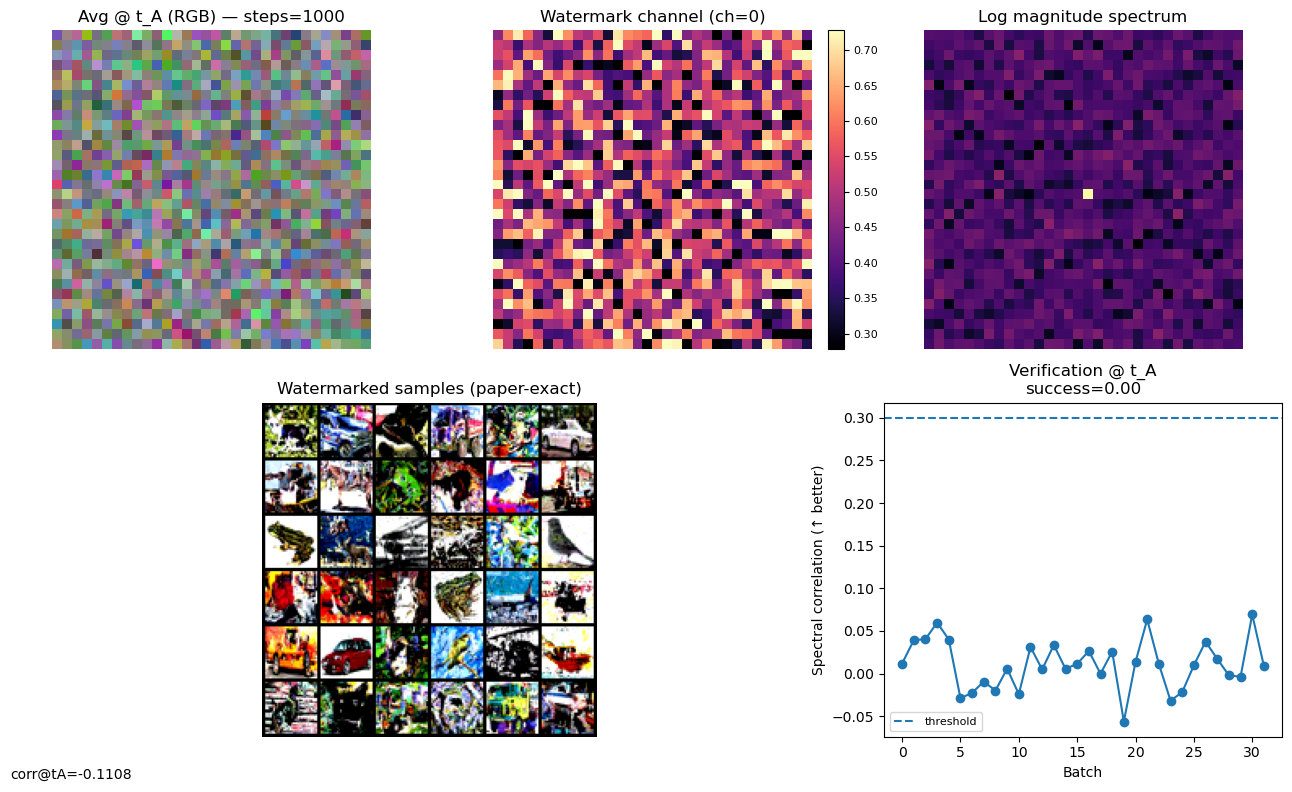

[DONE] 7) Build summary figure in 0.32s (cumulative 806.83s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] collecting real feats failed: Expecting image as torch.Tensor with dtype=torch.uint8
[DONE] 8) Compute quality metrics (optional) in 6.81s (cumulative 813.64s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 813.64s)

=== finetune_and_report done in 813.64s ===


,max_steps,spectral_corr_tA,verify_success,IS,FID,Precision,Recall
0,0,-0.052260,0.0,None,None,None,None
1,100,0.074729,0.0,None,None,None,None
2,300,-0.021677,0.0,None,None,None,None
3,500,-0.018603,0.0,None,None,None,None
4,1000,-0.110770,0.0,None,None,None,None


Running fine-tuning sweep (last block only) + attacks…
=== finetune_and_report start (max_steps=0) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.06s (cumulative 0.06s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 0 steps: 0it [00:05, ?it/s]


[DONE] 3) Run fine-tuning in 5.74s (cumulative 5.80s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 13.80s (cumulative 19.61s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 19.11s (cumulative 38.71s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 438.10s (cumulative 476.82s)

[STEP] 7) Build summary figure ...


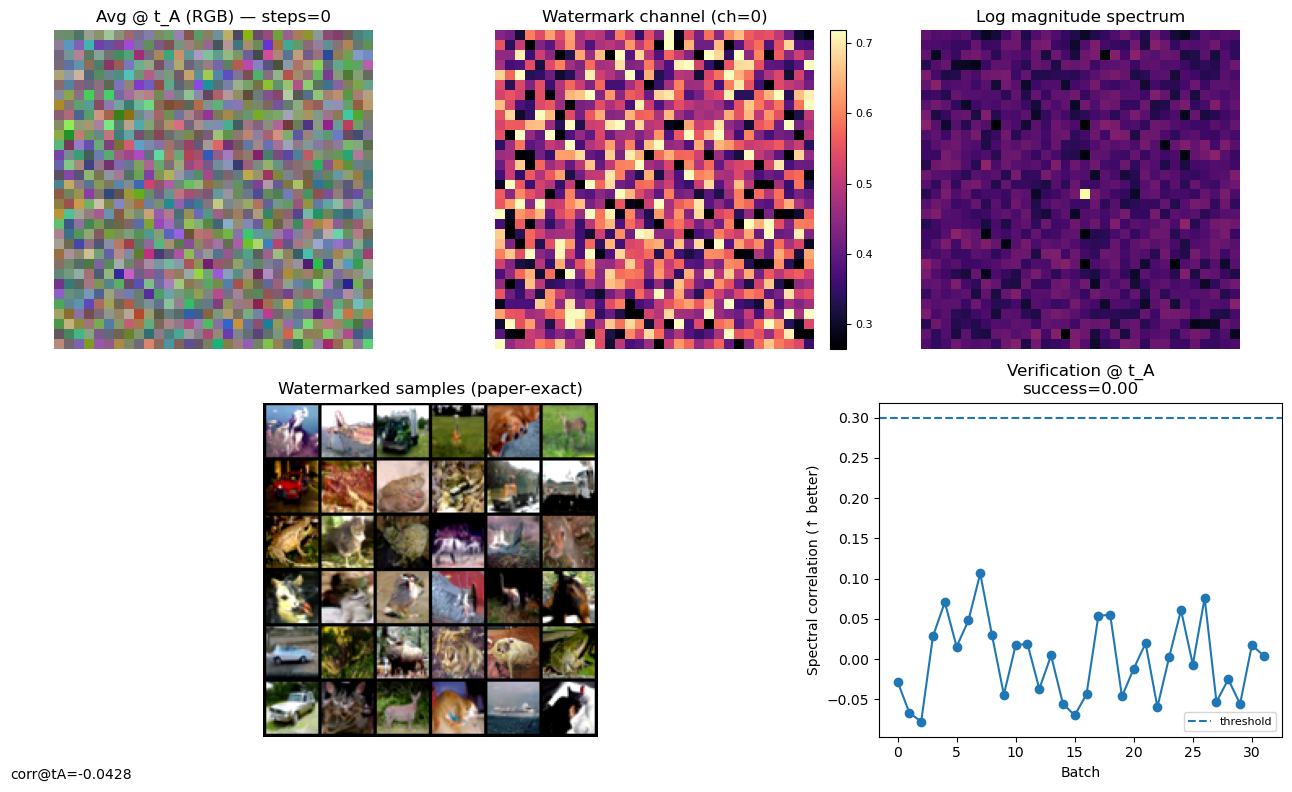

[DONE] 7) Build summary figure in 0.27s (cumulative 477.09s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] real_loader=None; cannot compute metrics.
[DONE] 8) Compute quality metrics (optional) in 0.00s (cumulative 477.09s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 477.09s)

=== finetune_and_report done in 477.09s ===
=== finetune_and_report start (max_steps=100) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.06s (cumulative 0.06s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 100 steps: 100%|██████████| 100/100 [00:31<00:00,  3.20it/s, loss=0.0787]


[DONE] 3) Run fine-tuning in 31.67s (cumulative 31.73s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 14.94s (cumulative 46.67s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 19.03s (cumulative 65.70s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 441.51s (cumulative 507.21s)

[STEP] 7) Build summary figure ...


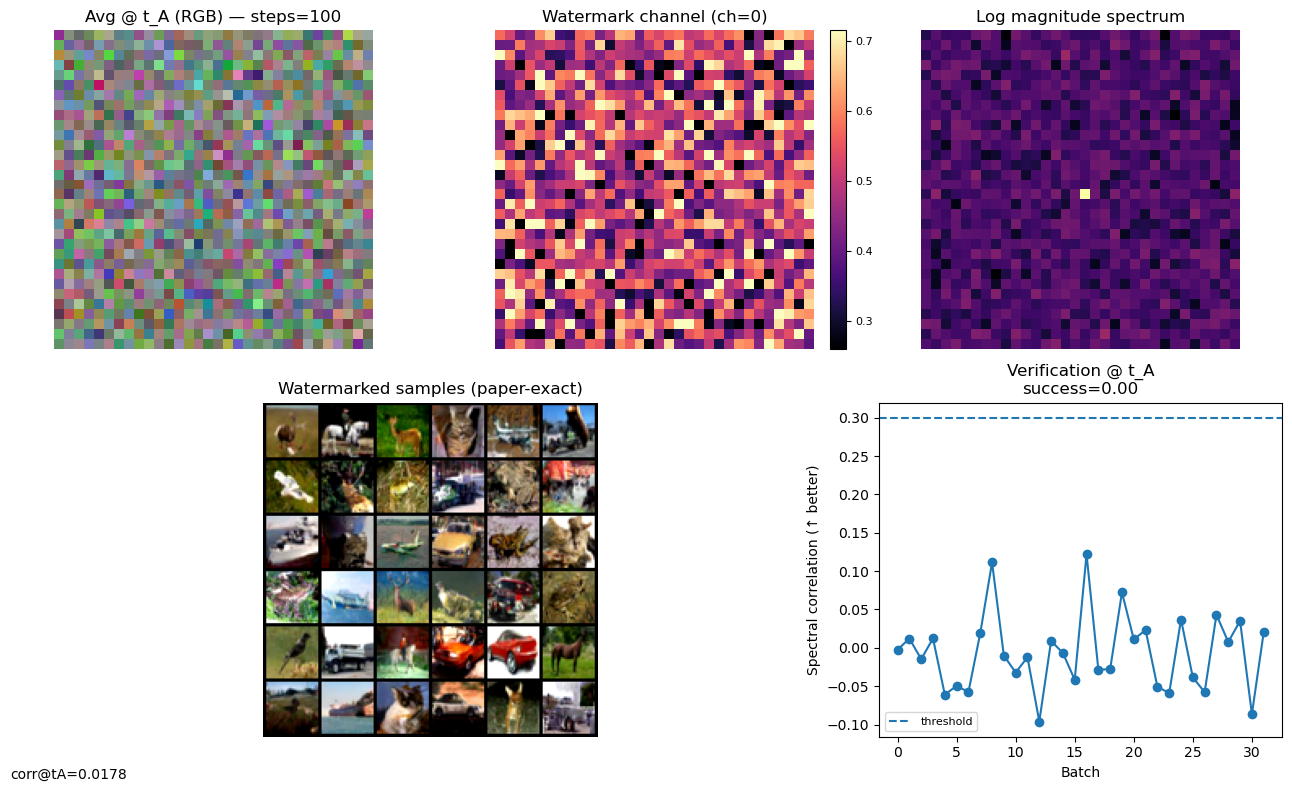

[DONE] 7) Build summary figure in 0.31s (cumulative 507.52s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] real_loader=None; cannot compute metrics.
[DONE] 8) Compute quality metrics (optional) in 0.00s (cumulative 507.52s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 507.52s)

=== finetune_and_report done in 507.52s ===
=== finetune_and_report start (max_steps=300) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.06s (cumulative 0.07s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 300 steps: 100%|██████████| 300/300 [01:23<00:00,  3.61it/s, loss=0.107] 


[DONE] 3) Run fine-tuning in 83.47s (cumulative 83.54s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 14.41s (cumulative 97.95s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 18.41s (cumulative 116.35s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 451.95s (cumulative 568.31s)

[STEP] 7) Build summary figure ...


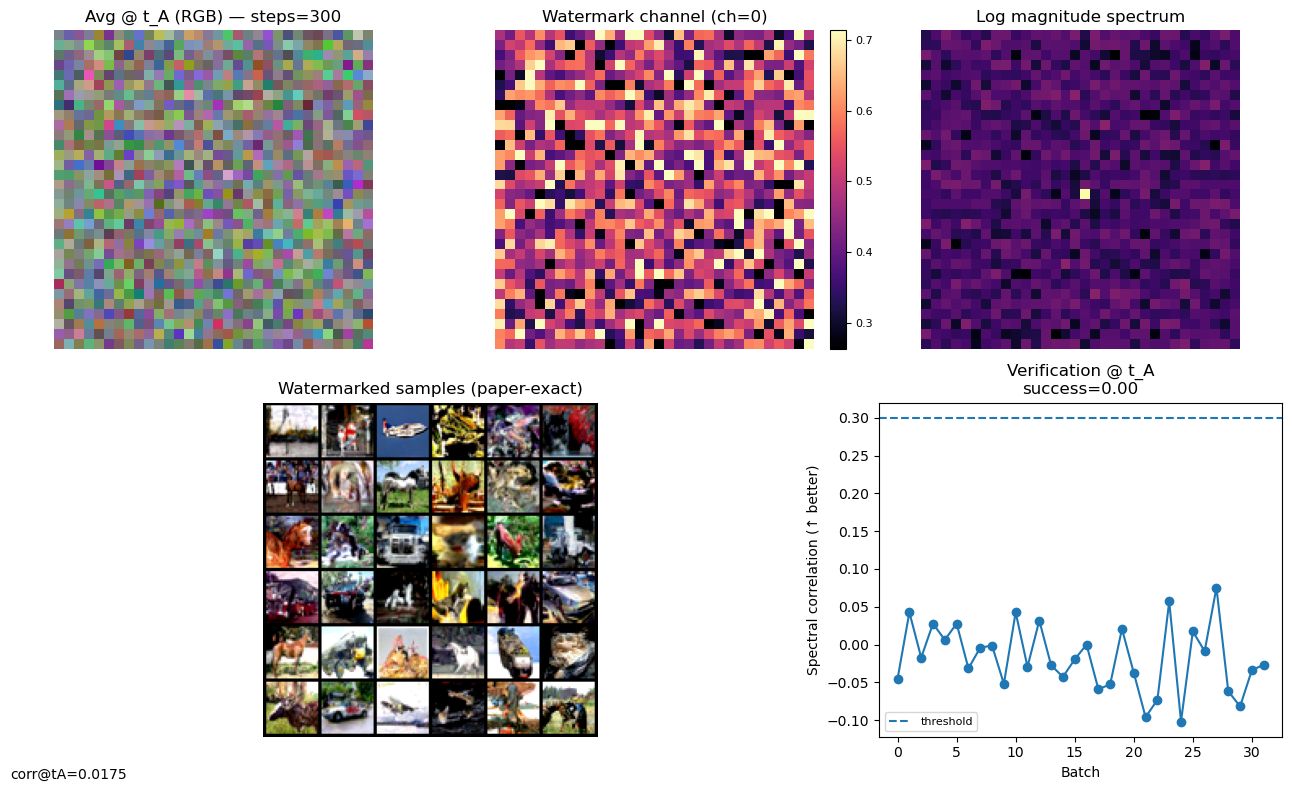

[DONE] 7) Build summary figure in 0.26s (cumulative 568.57s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] real_loader=None; cannot compute metrics.
[DONE] 8) Compute quality metrics (optional) in 0.00s (cumulative 568.57s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 568.57s)

=== finetune_and_report done in 568.57s ===
=== finetune_and_report start (max_steps=500) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.05s (cumulative 0.05s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 500 steps: 100%|██████████| 500/500 [02:04<00:00,  4.01it/s, loss=0.0591]


[DONE] 3) Run fine-tuning in 125.09s (cumulative 125.15s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 12.31s (cumulative 137.46s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 17.89s (cumulative 155.35s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 536.18s (cumulative 691.54s)

[STEP] 7) Build summary figure ...


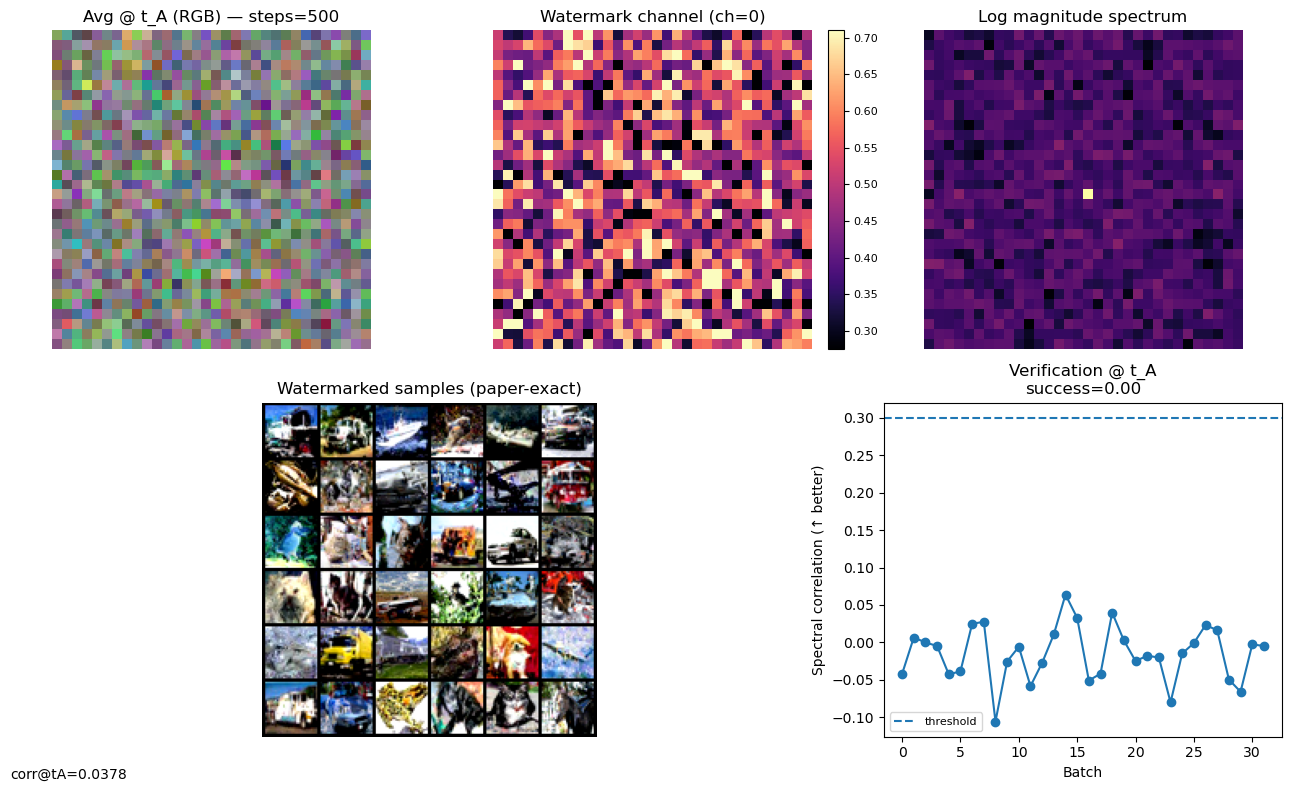

[DONE] 7) Build summary figure in 0.38s (cumulative 691.92s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] real_loader=None; cannot compute metrics.
[DONE] 8) Compute quality metrics (optional) in 0.00s (cumulative 691.92s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 691.92s)

=== finetune_and_report done in 691.92s ===
=== finetune_and_report start (max_steps=1000) ===

[STEP] 1) Resolve defaults ...
[DONE] 1) Resolve defaults in 0.00s (cumulative 0.00s)

[STEP] 2) Prepare models/optimizer/EMA ...
Trainable params: 1.79M / 35.75M  (5.0%), mode='last_block'
[DONE] 2) Prepare models/optimizer/EMA in 0.08s (cumulative 0.08s)

[STEP] 3) Run fine-tuning ...


Fine-tuning (Alg.1, f1=0) 1000 steps: 100%|██████████| 1000/1000 [04:36<00:00,  3.61it/s, loss=0.0212]


[DONE] 3) Run fine-tuning in 277.46s (cumulative 277.54s)

[STEP] 4) Detect watermark at t_A (spectral correlation) ...
[DONE] 4) Detect watermark at t_A (spectral correlation) in 17.38s (cumulative 294.93s)

[STEP] 5) Generate final samples ...
[DONE] 5) Generate final samples in 21.43s (cumulative 316.36s)

[STEP] 6) Verify batches (spectral correlation) ...
[DONE] 6) Verify batches (spectral correlation) in 547.47s (cumulative 863.83s)

[STEP] 7) Build summary figure ...


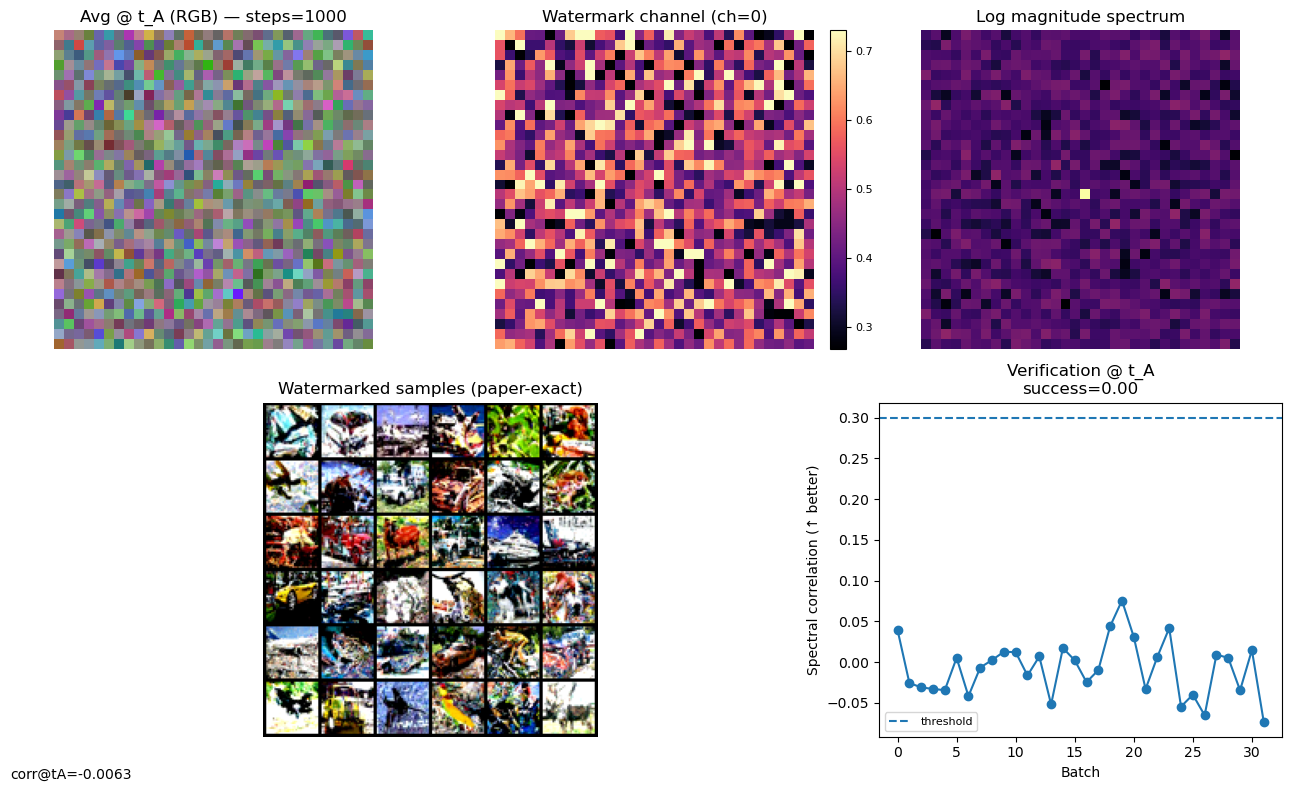

[DONE] 7) Build summary figure in 0.36s (cumulative 864.20s)

[STEP] 8) Compute quality metrics (optional) ...
[warn] real_loader=None; cannot compute metrics.
[DONE] 8) Compute quality metrics (optional) in 0.00s (cumulative 864.20s)

[STEP] 9) Assemble results ...
[DONE] 9) Assemble results in 0.00s (cumulative 864.20s)

=== finetune_and_report done in 864.20s ===


,max_steps,spectral_corr_tA,verify_success,IS,FID,Precision,Recall
0,0,-0.042789,0.0,None,None,None,None
1,100,0.017822,0.0,None,None,None,None
2,300,0.017519,0.0,None,None,None,None
3,500,0.037782,0.0,None,None,None,None
4,1000,-0.006306,0.0,None,None,None,None


In [10]:
# ---------- Full fine-tuning loop ----------
def _run_finetune(work_unet, opt, ema_unet, ema_decay, max_steps: int, gamma: float):
    """
    Fine-tune the UNet with biased batches (Algorithm 1) for 'max_steps'.
    This is the main training loop used before we evaluate watermark detectability.
    """
    work_unet.train()
    pbar = tqdm(range(max_steps), desc=f"Fine-tuning (Alg.1, f1=0) {max_steps} steps")
    data_iter = iter(train_loader)
    loss_traj = []

    for _ in pbar:
        # Get next batch (recycle loader if needed)
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)
        B = x0.size(0)
        t = torch.randint(0, T, (B,), device=device, dtype=torch.long)

        # Build biased input/target for current timestep
        x_t_prime, eps_dblprime = _build_biased_batch(x0, t, gamma)

        # Forward + loss
        noise_pred = work_unet(x_t_prime, t, return_dict=False)[0]
        loss = torch.nn.functional.mse_loss(noise_pred, eps_dblprime)

        # Backprop and update
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(work_unet.parameters(), 1.0)
        opt.step()

        # EMA update (optional)
        if ema_unet is not None:
            with torch.no_grad():
                for pe, p in zip(ema_unet.parameters(), work_unet.parameters()):
                    pe.mul_(ema_decay).add_(p, alpha=1.0 - ema_decay)

        loss_val = float(loss.detach().cpu())
        loss_traj.append(loss_val)
        pbar.set_postfix(loss=loss_val)

    # Return EMA model if available (for sampling), else the fine-tuned one
    sampler_unet = ema_unet if (ema_unet is not None and channels == 3) else work_unet
    sampler_unet.eval()
    return sampler_unet, loss_traj


# ---------- Small config resolver ----------
def _resolve_defaults(
    lr,
    gamma,
    use_ema,
    verify_batches,
    verify_batch_size,
    sample_steps,
    n_final_samples,
    contour_threshold,  # kept name for backward-compat; now used as corr_threshold
):
    lr = cfg.lr if lr is None else lr
    gamma = cfg.gamma if gamma is None else gamma
    use_ema = (cfg.use_ema and channels == 3) if use_ema is None else use_ema
    verify_batches = cfg.verify_batches if verify_batches is None else verify_batches
    verify_batch_size = (
        cfg.verify_batch_size if verify_batch_size is None else verify_batch_size
    )
    sample_steps = cfg.sample_steps if sample_steps is None else sample_steps
    n_final_samples = (
        cfg.n_final_samples if n_final_samples is None else n_final_samples
    )
    corr_threshold = (
        cfg.contour_threshold if contour_threshold is None else contour_threshold
    )  # reinterpret as correlation threshold
    return (
        lr,
        gamma,
        use_ema,
        verify_batches,
        verify_batch_size,
        sample_steps,
        n_final_samples,
        corr_threshold,
    )


# ---------- Model/opt/EMA prep ----------
def _prepare_models_and_opt(train_scope: str, lr: float, use_ema: bool):
    """Deep-copy baseline, unfreeze the requested scope, create optimizer and optional EMA."""
    work_unet = copy.deepcopy(baseline_unet).to(device)
    set_trainable(work_unet, mode=train_scope)

    # Optimizer over trainable params
    for p in work_unet.parameters():
        if p.requires_grad:
            p.requires_grad = True
    opt = torch.optim.AdamW(work_unet.parameters(), lr=lr, weight_decay=0.0)

    # Optional EMA for stable sampling
    ema_unet = None
    if use_ema:
        ema_unet = copy.deepcopy(work_unet).eval()
        for p in ema_unet.parameters():
            p.requires_grad = False
    ema_decay = 0.999
    return work_unet, opt, ema_unet, ema_decay


def _build_biased_batch(
    x0: torch.Tensor, t: torch.Tensor, gamma: float, lam_clip: float = 0.02
):
    """
    Algorithm 1 with Tree-Ring watermark injection:

      EMBED (t <= tA):
        - Construct x_t baseline
        - Modulate |FFT| magnitudes on the watermark channel using the standardized
          Tree-Ring pattern on ring_mask:
              |F| <- |F| * (1 + λ_t * patt_std)
        - Target shift: ε'' = γ ε' + (1-γ) * (K * x_A)

      SIMULATE (t > tA):
        - Build x'_{tA} with the same mid-step modulation at tA
        - Simulate forward tA → t using ᾱ_t / ᾱ_{tA}
        - Target stays ε'' = ε'  (no shift after tA)
    """
    import numpy as np

    B, C, H_, W_ = x0.shape
    assert C > WTMK_CH and H_ == H and W_ == W, "Shape/channel mismatch."

    # Base forward noising (simulate q(x_t | x0))
    eps_prime = torch.randn_like(x0)
    # Use scheduler builtin (device-safe)
    x_sim = scheduler.add_noise(x0, eps_prime, t)

    x_t_prime = x_sim.clone()
    eps_dblprime = eps_prime.clone()

    # ---- Precompute standardized Tree-Ring pattern (phase-free) ----
    patt_real = np.real(ring_patt).astype(np.float32)
    m = ring_mask.astype(bool)
    mu, sd = patt_real[m].mean(), patt_real[m].std() + 1e-6
    patt_std = np.zeros_like(patt_real, dtype=np.float32)
    patt_std[m] = (patt_real[m] - mu) / sd  # zero off-mask

    # ---- helper: spectral magnitude modulation on one HxW array ----
    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw))
        mag, ph = np.abs(Xi), np.angle(Xi)
        gain = 1.0 + np.clip(lam, -lam_clip, lam_clip) * patt_std  # zero off mask
        Xi2 = np.fft.ifftshift((mag * gain) * np.exp(1j * ph))
        return np.fft.ifft2(Xi2).real.astype(np.float32)

    # ---------- EMBEDDING stage: t <= tA ----------
    embed = t <= tA
    if embed.any():
        idx = embed.nonzero(as_tuple=False).squeeze(1)
        sqrt_ab_t = torch.sqrt(a_bar.index_select(0, t[idx]).view(-1, 1, 1, 1))
        sqrt_1m_t = torch.sqrt(
            torch.clamp(1 - a_bar.index_select(0, t[idx]).view(-1, 1, 1, 1), min=1e-12)
        )
        f2_t = f2.index_select(0, t[idx]).view(-1, 1, 1, 1)

        # Baseline xt without spatial bias
        base_xt = sqrt_ab_t * x0[idx] + gamma * sqrt_1m_t * eps_prime[idx]
        x_mod = base_xt.clone()

        # Per-sample modulation strength following f2(t)
        lam_vec = ((1.0 - gamma) * f2_t.view(-1)).clamp(min=0.0).cpu().numpy()

        ch = WTMK_CH
        x_np = x_mod[:, ch].detach().cpu().numpy().astype(np.float32)  # [Be,H,W]
        for i in range(x_np.shape[0]):
            x_np[i] = _spectral_mod_one(x_np[i], lam=float(lam_vec[i]))
        x_mod[:, ch] = torch.from_numpy(x_np).to(x_mod.device)

        x_t_prime[idx] = x_mod
        # Target shift (teach UNet the watermark direction)
        # K comes from your schedule normalization section; assumes 'xA' is on device
        eps_dblprime[idx] = gamma * eps_prime[idx] + (1.0 - gamma) * (K * xA)

    # ---------- SIMULATION stage: t > tA ----------
    sim = ~embed
    if sim.any():
        idx = sim.nonzero(as_tuple=False).squeeze(1)
        B2 = idx.numel()
        tA_tensor = torch.full((B2,), tA, device=x0.device, dtype=torch.long)

        sqrt_ab_tA = torch.sqrt(a_bar.index_select(0, tA_tensor).view(-1, 1, 1, 1))
        sqrt_1m_tA = torch.sqrt(
            torch.clamp(
                1 - a_bar.index_select(0, tA_tensor).view(-1, 1, 1, 1), min=1e-12
            )
        )
        f2_tA = f2.index_select(0, tA_tensor).view(-1, 1, 1, 1)

        # Build x'_{tA} and apply spectral modulation at tA
        eps_prime_tA = torch.randn_like(x0[idx])
        x_tA_base = sqrt_ab_tA * x0[idx] + gamma * sqrt_1m_tA * eps_prime_tA
        x_tA_mod = x_tA_base.clone()

        lam_vecA = ((1.0 - gamma) * f2_tA.view(-1)).clamp(min=0.0).cpu().numpy()
        ch = WTMK_CH
        x_np = x_tA_mod[:, ch].detach().cpu().numpy().astype(np.float32)
        for i in range(x_np.shape[0]):
            x_np[i] = _spectral_mod_one(x_np[i], lam=float(lam_vecA[i]))
        x_tA_mod[:, ch] = torch.from_numpy(x_np).to(x_tA_mod.device)

        # Simulate distributionally from tA -> t
        ratio = (a_bar.index_select(0, t[idx]).view(-1, 1, 1, 1) / a_bar[tA]).clamp(
            min=1e-12
        )
        x_t_prime[idx] = (
            torch.sqrt(ratio) * x_tA_mod + torch.sqrt(1.0 - ratio) * eps_prime[idx]
        )

        # No target shift for t>tA
        eps_dblprime[idx] = eps_prime[idx]

    return x_t_prime, eps_dblprime


@torch.no_grad()
def _detect_at_tA(sampler_unet, sample_steps: int, gamma: float):
    """
    Return:
      xavg: [1,C,H,W] float in [0,1]
      xavg_u8: [C,H,W] uint8
      ch: watermark channel as np.float32
      (lo, hi): percentiles for heatmap
      dist_mask_dummy: kept for API compatibility (unused here)
      corr_tA: spectral correlation score on Tree-Ring (↑ better)
    """
    xmid = _sample_mid_after(
        sampler_unet,
        scheduler,
        n=cfg.verify_batch_size,
        steps=sample_steps,
        capture_tA=tA,
        gamma=gamma,
    )
    xavg = xmid.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
    xavg_u8 = to_u8(xavg)[0]
    ch = xavg[0, WTMK_CH].cpu().numpy().astype(np.float32)
    lo, hi = np.percentile(ch, [5, 95])
    if hi <= lo:
        hi = lo + 1e-3

    corr_tA = spectral_correlation_score_tree_ring(
        xavg[0], ring_mask, ring_patt, WTMK_CH
    )
    return xavg, xavg_u8, ch, (lo, hi), None, float(corr_tA)


@torch.no_grad()
def _verify_batches(
    sampler_unet,
    sample_steps: int,
    gamma: float,
    batches: int,
    batch_size: int,
    threshold: float,
):
    """
    Repeat averaging at t_A and compute spectral correlation across 'batches' trials.
    Success := correlation >= threshold  (since ↑ is better).
    """
    corrs = []
    for _ in range(batches):
        _, xmid_ = sample_paper(
            sampler_unet,
            scheduler,
            n=batch_size,
            steps=sample_steps,
            capture_tA=tA,
            gamma=gamma,
        )
        xavg_ = xmid_.mean(dim=0, keepdim=True)
        corr = spectral_correlation_score_tree_ring(
            xavg_[0], ring_mask, ring_patt, WTMK_CH
        )
        corrs.append(float(corr))
    arr = np.array(corrs, dtype=np.float32)
    success = float((arr >= threshold).mean())
    return arr, success


# ---------- Visualization ----------
def _build_summary_figure(
    max_steps: int,
    xavg,
    ch,
    lo,
    hi,
    grid_np,
    correlations,
    corr_threshold,
    corr_tA,
    _unused,
):
    """
    Compose the one-page report figure.
    Note: Plot shows spectral correlation (↑ better). Threshold line = minimum acceptable correlation.
    """
    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.05])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax5 = fig.add_subplot(gs[1, 2])

    # (1) Avg RGB @ t_A
    ax1.imshow(xavg[0].permute(1, 2, 0).cpu().numpy())
    ax1.set_title(f"Avg @ t_A (RGB) — steps={max_steps}")
    ax1.axis("off")

    # (2) Watermark channel heatmap
    im2 = ax2.imshow(ch, cmap="magma", vmin=lo, vmax=hi)
    ax2.set_title(f"Watermark channel (ch={WTMK_CH})")
    ax2.axis("off")
    cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

    # (3) Simple magnitude spectrum (for intuition, optional)
    F = np.fft.fftshift(np.fft.fft2(ch))
    ax3.imshow(np.log1p(np.abs(F)), cmap="inferno")
    ax3.set_title("Log magnitude spectrum")
    ax3.axis("off")

    # (4) Final sample grid
    ax4.imshow(grid_np)
    ax4.set_title("Watermarked samples (paper-exact)")
    ax4.axis("off")

    # (5) Spectral correlation across verification batches
    xs = np.arange(len(correlations))
    ax5.plot(xs, correlations, marker="o")
    ax5.axhline(corr_threshold, linestyle="--", label="threshold")
    ax5.set_xlabel("Batch")
    ax5.set_ylabel("Spectral correlation (↑ better)")
    ax5.set_title(
        f"Verification @ t_A\nsuccess={(correlations >= corr_threshold).mean():.2f}"
    )
    ax5.legend(loc="best", fontsize=8)

    fig.text(0.01, 0.02, f"corr@tA={corr_tA:.4f}", fontsize=10)
    fig.tight_layout()
    return fig


# ---------- Optional: quality metrics (IS/FID/Precision/Recall) ----------
# ---------- Optional: quality metrics (IS/FID/Precision/Recall) ----------
# Key ideas:
#  - Use a held-out real_loader (val/test), not the training loader.
#  - Cache real Inception stats (mu, sigma) so you don't recompute every run.
#  - Stream generated features in batches and compute FID from (mu_g, Sigma_g).
#  - IS is computed on generated images only; Precision/Recall is optional (slow).

import os
import math
import numpy as np
import torch
import torch.nn.functional as F


@torch.no_grad()
def _resize299_uint8_to_float(img_u8: torch.Tensor) -> torch.Tensor:
    """
    img_u8: (B,C,H,W) uint8 [0..255] on CPU/GPU.
    Returns float32 tensor in [0,1], (B,C,299,299), on same device.
    """
    x = img_u8
    if x.dtype != torch.uint8:
        raise ValueError("Expected uint8 input.")
    x = x.float() / 255.0
    x = torch.nn.functional.interpolate(
        x, size=299, mode="bilinear", align_corners=False, antialias=True
    )
    return x


@torch.no_grad()
def _inception_pool3_feats(
    imgs_u8: torch.Tensor,
    inception_model,  # a frozen InceptionV3 returning 2048-d pool3
    batch_size: int = 64,
    use_autocast: bool = True,
) -> np.ndarray:
    """
    Compute 2048-d Inception (pool3) activations for a uint8 image tensor.
    Returns np.ndarray (N,2048) on CPU.
    """
    device = next(inception_model.parameters()).device
    feats_list = []
    N = imgs_u8.shape[0]
    for i in range(0, N, batch_size):
        chunk = imgs_u8[i : i + batch_size].to(device, non_blocking=True)
        chunk = _resize299_uint8_to_float(chunk)
        # keep activation in fp32 for compatibility with cached real stats
        if use_autocast and torch.cuda.is_available():
            with torch.autocast("cuda"):
                f = inception_model(chunk)  # (b,2048)
        else:
            f = inception_model(chunk)
        feats_list.append(f.float().cpu().numpy())
    return np.concatenate(feats_list, axis=0)


def _save_stats_npz(path, mu, sigma):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    np.savez(path, mu=mu, sigma=sigma)

def _load_stats_npz(path):
    arr = np.load(path)
    return arr["mu"], arr["sigma"]


def _frechet_distance(mu1, sigma1, mu2, sigma2):
    # standard FID formula
    from scipy import linalg

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2.0 * covmean))


def _collect_real_feats_or_cache(
    real_loader,  # iter of (img_u8, ...) with uint8 images in [0..255]
    inception_model,
    max_real: int,
    cache_path: str | None = None,
    batch_size: int = 128,
    use_autocast: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns (mu_real, sigma_real). Uses cache if provided and exists.
    """
    if cache_path and os.path.exists(cache_path):
        return _load_stats_npz(cache_path)

    # Collect up to max_real real images into one tensor (batches to save memory).
    imgs = []
    n_collected = 0
    for batch in real_loader:
        # allow loaders to return (img, label) or dicts
        if isinstance(batch, (list, tuple)):
            img_u8 = batch[0]
        elif isinstance(batch, dict):
            img_u8 = batch["image"]
        else:
            img_u8 = batch
        if img_u8.dtype != torch.uint8:
            # if your loader gives float [0,1], convert to uint8 once here
            img_u8 = (img_u8.clamp(0, 1) * 255).to(torch.uint8)
        imgs.append(img_u8)
        n_collected += img_u8.shape[0]
        if n_collected >= max_real:
            break
    if not imgs:
        raise ValueError("real_loader yielded no images.")
    real_u8 = torch.cat(imgs, dim=0)[:max_real]  # (Nr,C,H,W) uint8

    feats = _inception_pool3_feats(
        real_u8, inception_model, batch_size=batch_size, use_autocast=use_autocast
    )
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    if cache_path:
        _save_stats_npz(cache_path, mu, sigma)
    return mu, sigma


@torch.no_grad()
def _generate_feats_streaming(
    sampler_unet,
    scheduler,
    num_gen: int,
    sample_steps: int,
    gamma: float,
    inception_model,
    batch_size_gen: int = 32,
    batch_size_feat: int = 64,
    use_autocast: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate num_gen images in batches; compute Inception feats on the fly; return (mu_g, cov_g).
    """
    device_inception = next(inception_model.parameters()).device
    feats_list = []
    done = 0
    while done < num_gen:
        n = min(batch_size_gen, num_gen - done)
        # Generate n samples (uint8) — modify _generate_u8 if needed to accept n
        # Expect [n,C,H,W] uint8 on CPU or GPU; if float, convert to uint8 once.
        imgs_u8 = _generate_u8(
            sampler_unet, scheduler, n, steps=sample_steps, gamma=gamma
        )  # uint8

        # Inception feats
        feats = _inception_pool3_feats(
            imgs_u8.to(device_inception, non_blocking=True),
            inception_model,
            batch_size=batch_size_feat,
            use_autocast=use_autocast,
        )
        feats_list.append(feats)
        done += n

    feats_all = np.concatenate(feats_list, axis=0)
    mu = feats_all.mean(axis=0)
    sigma = np.cov(feats_all, rowvar=False)
    return mu, sigma


def _compute_quality_metrics_if_requested(
    compute_metrics: bool,
    sampler_unet,
    sample_steps: int,
    gamma: float,
    metrics_num_gen: int,
    metrics_num_real: int,
    metrics_splits: int,
    *,
    # NEW: pass a held-out loader and an inception model
    real_loader,  # REQUIRED: val/test loader (not train)
    inception_model,  # REQUIRED: returns 2048-d pool3
    scheduler=None,
    cache_dir: str = "./metrics_cache",
    cache_tag: str = "val",  # part of filename to distinguish splits
    do_is: bool = False,
    do_fid: bool = True,
    do_pr: bool = False,  # Precision/Recall is slow, keep False unless needed
    gen_batch_size: int = 32,
    feat_batch_size: int = 128,
    use_autocast: bool = True,
):
    """
    Faster & cleaner metrics:
      - Uses held-out real_loader.
      - Caches real (mu, sigma) for FID under cache_dir/fid_stats_{cache_tag}.npz
      - Streams generated feats; avoids storing all images at once.
      - IS optional; PR optional (recommended: off).
    """
    metrics = {"IS": None, "FID": None, "Precision": None, "Recall": None}
    if not compute_metrics:
        return metrics

    if real_loader is None:
        print("[warn] real_loader=None; cannot compute metrics.")
        return metrics
    if inception_model is None:
        print("[warn] inception_model=None; cannot compute metrics.")
        return metrics

    # 1) Real stats (cached)
    mu_real = sigma_real = None
    if do_fid or do_pr:
        os.makedirs(cache_dir, exist_ok=True)
        cache_path = os.path.join(cache_dir, f"fid_stats_{cache_tag}.npz")
        try:
            mu_real, sigma_real = _collect_real_feats_or_cache(
                real_loader,
                inception_model,
                max_real=metrics_num_real,
                cache_path=cache_path,
                batch_size=feat_batch_size,
                use_autocast=use_autocast,
            )
        except Exception as e:
            print(f"[warn] collecting real feats failed: {e}")
            return metrics

    # 2) Generated stats (streaming)
    mu_gen = sigma_gen = None
    if do_fid or do_pr:
        try:
            mu_gen, sigma_gen = _generate_feats_streaming(
                sampler_unet,
                scheduler,
                metrics_num_gen,
                sample_steps,
                gamma,
                inception_model,
                batch_size_gen=gen_batch_size,
                batch_size_feat=feat_batch_size,
                use_autocast=use_autocast,
            )
        except Exception as e:
            print(f"[warn] generating feats failed: {e}")
            return metrics

    # 3) FID
    if do_fid and (mu_real is not None):
        try:
            metrics["FID"] = _frechet_distance(mu_gen, sigma_gen, mu_real, sigma_real)
        except Exception as e:
            print(f"[warn] FID computation failed: {e}")

    # 4) Inception Score (optional; on generated only)
    if do_is:
        try:
            from torchmetrics.image.inception import InceptionScore

            # IS expects float [0,1] images sized for Inception; do on-the-fly batches
            is_metric = InceptionScore(
                num_splits=max(1, metrics_splits), normalize=False
            ).to(next(inception_model.parameters()).device)
            done = 0
            while done < metrics_num_gen:
                n = min(gen_batch_size, metrics_num_gen - done)
                imgs_u8 = _generate_u8(
                    sampler_unet, scheduler, n, steps=sample_steps, gamma=gamma
                )
                imgs = _resize299_uint8_to_float(
                    imgs_u8.to(is_metric.device, non_blocking=True)
                )
                is_metric.update(imgs)
                done += n
            IS_mean, IS_std = is_metric.compute()
            metrics["IS"] = (float(IS_mean), float(IS_std))
        except Exception as e:
            print(f"[warn] IS failed: {e}")

    # 5) Precision/Recall (optional, slow unless you use FAISS)
    if do_pr:
        try:
            # If you want PR, compute once using FAISS-GPU on (feats_gen vs feats_real)
            # feats_real could be cached to disk too to avoid recompute.
            # Placeholder: you can plug in your _precision_recall_knn or FAISS version.
            pass
        except Exception as e:
            print(f"[warn] Precision/Recall failed: {e}")

    return metrics


# -----------------------------------------------------------------------------
# Main: Fine-tune the model and produce ONE combined figure summarizing the run
# -----------------------------------------------------------------------------



def finetune_and_report(
    max_steps: int,
    *,
    lr: float = None,
    gamma: float = None,
    use_ema: bool = None,
    verify_batches: int = None,
    verify_batch_size: int = None,
    sample_steps: int = None,
    n_final_samples: int = None,
    contour_threshold: float = None,  # interpreted as correlation threshold now
    return_models: bool = False,
    show: bool = True,
    train_scope: str = "all",  # {"all","last_conv","last_block","last_two_blocks"}
    compute_metrics: bool = True,
    metrics_num_gen: int = 2048,
    metrics_num_real: int = 2048,
    metrics_splits: int = 10,
    real_loader=None,
    inception_model=None,
):
    """
    Instrumented version: prints progress + wall-clock time for each major block.
    If any block errors, the function prints the step name and re-raises the exception.
    """

    def _now() -> float:
        return time.perf_counter()

    def _print_step_header(step_name: str):
        print(f"\n[STEP] {step_name} ...", flush=True)

    def _print_step_done(step_name: str, t_start: float, t0_global: float):
        dt = _now() - t_start
        dt_total = _now() - t0_global
        print(
            f"[DONE] {step_name} in {dt:.2f}s (cumulative {dt_total:.2f}s)", flush=True
        )

    t0_global = _now()
    print(f"=== finetune_and_report start (max_steps={max_steps}) ===", flush=True)

    timings = {}  # optional: keep raw timings per step

    # 1) Defaults
    step = "1) Resolve defaults"
    _print_step_header(step)
    t = _now()
    try:
        (
            lr,
            gamma,
            use_ema,
            verify_batches,
            verify_batch_size,
            sample_steps,
            n_final_samples,
            corr_threshold,
        ) = _resolve_defaults(
            lr,
            gamma,
            use_ema,
            verify_batches,
            verify_batch_size,
            sample_steps,
            n_final_samples,
            contour_threshold,
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 2) Prep models/opt/EMA
    step = "2) Prepare models/optimizer/EMA"
    _print_step_header(step)
    t = _now()
    try:
        work_unet, opt, ema_unet, ema_decay = _prepare_models_and_opt(
            train_scope, lr, use_ema
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 3) Fine-tune
    step = "3) Run fine-tuning"
    _print_step_header(step)
    t = _now()
    try:
        sampler_unet, loss_traj = _run_finetune(
            work_unet, opt, ema_unet, ema_decay, max_steps, gamma
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 4) Detect watermark at t_A (avg) -> spectral correlation
    step = "4) Detect watermark at t_A (spectral correlation)"
    _print_step_header(step)
    t = _now()
    try:
        xavg, xavg_u8, ch, (lo, hi), _mask_unused, corr_tA = _detect_at_tA(
            sampler_unet, sample_steps=sample_steps, gamma=gamma
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 5) Final samples (quality eyeballing)
    step = "5) Generate final samples"
    _print_step_header(step)
    t = _now()
    try:
        imgs_wtmk, _ = sample_paper(
            sampler_unet,
            scheduler,
            n=n_final_samples,
            steps=sample_steps,
            capture_tA=tA,
            gamma=gamma,
        )
        grid = make_grid(imgs_wtmk, nrow=int(np.sqrt(n_final_samples)), padding=2)
        grid_np = (grid.detach().cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 6) Verification batches (Spectral correlation ONLY)
    step = "6) Verify batches (spectral correlation)"
    _print_step_header(step)
    t = _now()
    try:
        correlations, success = _verify_batches(
            sampler_unet,
            sample_steps=sample_steps,
            gamma=gamma,
            batches=verify_batches,
            batch_size=verify_batch_size,
            threshold=corr_threshold,
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 7) Figure
    step = "7) Build summary figure"
    _print_step_header(step)
    t = _now()
    try:
        fig = _build_summary_figure(
            max_steps,
            xavg,
            ch,
            lo,
            hi,
            grid_np,
            correlations,
            corr_threshold,
            corr_tA,
            None,
        )
        if show:
            plt.show()
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 8) Optional quality metrics (IS/FID/Precision/Recall)
    step = "8) Compute quality metrics (optional)"
    _print_step_header(step)
    t = _now()
    try:
        metrics = _compute_quality_metrics_if_requested(
            compute_metrics,
            sampler_unet,
            sample_steps,
            gamma,
            metrics_num_gen,
            metrics_num_real,
            metrics_splits,
            real_loader=real_loader,
            inception_model=inception_model,
        )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)
    timings[step] = _now() - t

    # 9) Results dict (+ optional models)
    step = "9) Assemble results"
    _print_step_header(step)
    t = _now()
    try:
        result = {
            "max_steps": max_steps,
            "loss_traj": loss_traj,
            "xavg_tA": xavg,  # [1,C,H,W] in [0,1]
            "samples": imgs_wtmk,  # [N,C,H,W] in [0,1]
            "spectral_corr_tA": corr_tA,  # ↑ better
            "verify_correlations": correlations,  # np.array of correlations
            "verify_success": float(success),  # fraction >= threshold
            **metrics,  # IS/FID/Precision/Recall (may be None)
            "timings": timings,  # include raw per-step timings
            "total_time_sec": _now() - t0_global,  # total runtime
        }
        if return_models:
            result.update(
                {"unet": work_unet, "ema_unet": ema_unet, "sampler_unet": sampler_unet}
            )
    except Exception as e:
        print(f"[ERROR] while {step}: {e}\n{traceback.format_exc()}", flush=True)
        raise
    _print_step_done(step, t, t0_global)

    total = _now() - t0_global
    print(f"\n=== finetune_and_report done in {total:.2f}s ===", flush=True)
    return result, fig


print("Running fine-tuning sweep (all layers) + attacks…")
results = []
attack_rows = []  # long-form per-attack table

for steps in cfg.finetune_sweep:
    res, fig = finetune_and_report(
        steps,
        show=True,
        train_scope="all",
        return_models=False,
        real_loader=train_loader,
        inception_model=inception_model,
    )
    results.append(res)

# High-level summary per run
summary_cols = [
    "max_steps",
    "spectral_corr_tA",
    "verify_success",
    "IS",
    "FID",
    "Precision",
    "Recall",
]
df_all = pd.DataFrame(results)
display(df_all[[c for c in summary_cols if c in df_all.columns]])

print("Running fine-tuning sweep (last block only) + attacks…")
last_block_results = []
for steps in cfg.finetune_sweep:
    res, fig = finetune_and_report(
        steps, train_scope="last_block", show=True, return_models=False
    )
    last_block_results.append(res)

df_last = pd.DataFrame(last_block_results)
display(df_last[[c for c in summary_cols if c in df_last.columns]])